## NEUS for DEC

In [1]:
from shapely.geometry import Polygon, Point, MultiPolygon
import shapefile
import geopandas as gpd
import xarray as xr
import time
import numpy as np
from scipy.stats import linregress
import seaborn as sns
from scipy.interpolate import interp1d as int1
import matplotlib.pyplot as plt
%matplotlib inline
from shapely.geometry import Polygon, Point, MultiPolygon
import shapefile
import geopandas as gpd
import cartopy
import cartopy.crs as ccrs
import geopandas as gpd
import pandas as pn
import os
import scipy
import matplotlib
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import matplotlib.pyplot as plt
import mapclassify as mc
import matplotlib.colors
from matplotlib import gridspec
import random

/Users/nyelab/miniconda3/lib/python3.8/site-packages/geopandas/_compat.py:106: UserWarning: The Shapely GEOS version (3.8.0-CAPI-1.13.1 ) is incompatible with the GEOS version PyGEOS was compiled with (3.10.3-CAPI-1.16.1). Conversions between both will be slow.
  warnings.warn(


In [ ]:
# Load EPU shapefile
LME = gpd.read_file('/Users/nyelab/Downloads/LME66/LMEs66.shp')
# Load NYB shapefile
NYB = gpd.read_file('/Users/nyelab/Desktop/NYB Indicators/Datasets/Shapefiles/PlanningArea_NYocean_NYSDOS.shp')
# Alter the projection to WGS84 see https://epsg.io/4326
NYB = NYB.to_crs(epsg=4326)

In [ ]:
neus = xr.open_dataset('/Users/nyelab/Desktop/ClimateVelocity_Vertical/LME_data_files/Northeast_US_Continental_Shelf_vcv.nc')
neus_h = xr.open_dataset('/Users/nyelab/Desktop/ClimateVelocity_Vertical/LME_data_files/Northeast_US_Continental_Shelf_hcv_revised.nc')

In [ ]:
def new_vertical(data):
    data['v_spatgrad2'] = data.v_spatgrad/2
    data['VCV2'] = data.temptrend/data.v_spatgrad2.transpose('lat','lon','depth')
    return data

In [ ]:
neus = new_vertical(neus)

In [ ]:
neus_h

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [283,296,34.5,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.HCV,levels = np.arange(0,10, .5), extend = 'max',cmap='viridis',linewidths = 2.5,transform=ccrs.PlateCarree())
cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('Horizontal Climate Velocity at the Surface', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

gl = ax[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [283,296,34.5,46]
ax[1].set_extent(extent)
ax[1].coastlines(resolution='10m')
CS = ax[1].contourf(neus.lon,neus.lat,np.nanmedian(neus.VCV2,2),levels = np.arange(-1,0, .1), extend = 'both',cmap='magma',linewidths = 2.5,transform=ccrs.PlateCarree())
cbar = plt.colorbar(CS,shrink=0.25, ax = ax[1])
cbar.ax.tick_params(labelsize=14) 
#ax[1].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[1].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[1].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'lightgreen', linewidth =3)#hatch='xxxx')
ax[1].set_title('Median Vertical Climate Velocity', fontsize = 16)
ax[1].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

ax[1].plot([-72.5,-72.5], [41,38.5], linewidth = 2)

ax[0].scatter(-72.75, 40, color = 'magenta')
ax[0].scatter(new_lon, new_lat, color = 'yellow')

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [283,296,34.5,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.HCV,levels = np.arange(0,10, .5), extend = 'max',cmap='viridis',linewidths = 2.5,transform=ccrs.PlateCarree())
cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('Horizontal Climate Velocity at the Surface', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

gl = ax[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [283,296,34.5,46]
ax[1].set_extent(extent)
ax[1].coastlines(resolution='10m')
CS = ax[1].contourf(neus.lon,neus.lat,np.nanmedian(neus.VCV2,2),levels = np.arange(-1,0, .1), extend = 'both',cmap='magma',linewidths = 2.5,transform=ccrs.PlateCarree())
cbar = plt.colorbar(CS,shrink=0.25, ax = ax[1])
cbar.ax.tick_params(labelsize=14) 
#ax[1].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[1].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[1].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'lightgreen', linewidth =3)#hatch='xxxx')
ax[1].set_title('Median Vertical Climate Velocity', fontsize = 16)
ax[1].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

ax[1].plot([-72.5,-72.5], [41,38.5], linewidth = 2)

ax[0].scatter(-72.75, 40, color = 'magenta')
ax[0].scatter(new_lon, new_lat, color = 'yellow')

In [ ]:
np.diff(neus_h.lon)/2

In [ ]:
lat_start = neus_h.lat[63] #latitude 110.574 per 1 deg
lon_start = neus_h.lon[60] # longitude 111.320*cos(latitude)
neus_h.ew_spatgrad[63,60] #-0.002856
neus_h.ns_spatgrad[63,60] #-0.005632
angle = np.rad2deg(np.arctan(neus_h.ns_spatgrad[63,60]/neus_h.ew_spatgrad[63,60]))
n_mov = neus_h.HCV[63,60]*np.sin(np.arctan(neus_h.ns_spatgrad[63,60]/neus_h.ew_spatgrad[63,60]))
e_mov = neus_h.HCV[63,60]*np.cos(np.arctan(neus_h.ns_spatgrad[63,60]/neus_h.ew_spatgrad[63,60]))
n_mov_deg = n_mov/110.574
e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
new_lat = lat_start + n_mov_deg
new_lon = lon_start + e_mov_deg 

if new_lat > lat_start + 0.04166603:
    lat_index = lat_index + 1
if new_lat < lat_start - 0.04166603:
    lat_index = lat_index - 1
if new_lon > lon_start + 0.04166794:
    lon_index = lon_index +1
if new_lon < lon_start - 0.04166794:
    lon_index = lon_index - 1

In [ ]:
lat_index = 63
lon_index = 60
new_lat = np.empty(20)
new_lon = np.empty(20)
for i in range(20):
    lat_start = neus_h.lat[lat_index] #latitude 110.574 per 1 deg
    lon_start = neus_h.lon[lon_index] # longitude 111.320*cos(latitude)
    n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
    if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
        if n_mov < 0:
            n_mov = n_mov*-1
        if e_mov < 0:
            e_mov = e_mov*-1
    # southeast trajectory
    if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
        if n_mov > 0:
            n_mov = n_mov*-1
        if e_mov < 0:
            e_mov = e_mov*-1
    # southwest trajectory
    if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
        if n_mov > 0:
            n_mov = n_mov*-1
        if e_mov > 0:
            e_mov = e_mov*-1
    # northwest trajectory
    if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
        if n_mov < 0:
            n_mov = n_mov*-1
        if e_mov > 0:
            e_mov = e_mov*-1
    
    n_mov_deg = n_mov/110.574
    e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
    if i == 0:
        new_lat[i] = lat_start + n_mov_deg
        new_lon[i] = lon_start + e_mov_deg
    if i > 0:
        new_lat[i] = new_lat[i-1] + n_mov_deg
        new_lon[i] = new_lon[i-1] + e_mov_deg
    
    if new_lat[i] > lat_start + 0.04166603:
        lat_index = lat_index + 1
    if new_lat[i] < lat_start - 0.04166603:
        lat_index = lat_index - 1
    if new_lon[i] > lon_start + 0.04166794:
        lon_index = lon_index +1
    if new_lon[i] < lon_start - 0.04166794:
        lon_index = lon_index - 1

In [ ]:
#import random
 
# Generates a random number between
# a given positive range
#r1 = random.randint(0, 10)

lat_index = 63
lon_index = 60
new_lat50 = np.empty([50,10])
new_lon50 = np.empty([50,10])
lon_list =[60,65,55,55,75,75,68,62,52,62]
lat_list = [63,63,60,53,64,70,70,68,66,57]
for j in range(10):
    lat_index = lat_list[j]
    lon_index = lon_list[j]
    for i in range(50):
        lat_start = neus_h.lat[lat_index] #latitude 110.574 per 1 deg
        lon_start = neus_h.lon[lon_index] # longitude 111.320*cos(latitude)
        n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
        e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
        if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
            if n_mov < 0:
                n_mov = n_mov*-1
            if e_mov < 0:
                e_mov = e_mov*-1
    # southeast trajectory
        if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
            if n_mov > 0:
                n_mov = n_mov*-1
            if e_mov < 0:
                e_mov = e_mov*-1
    # southwest trajectory
        if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
            if n_mov > 0:
                n_mov = n_mov*-1
            if e_mov > 0:
                e_mov = e_mov*-1
    # northwest trajectory
        if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
            if n_mov < 0:
                n_mov = n_mov*-1
            if e_mov > 0:
                e_mov = e_mov*-1
    
        n_mov_deg = n_mov/110.574
        e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
        if i == 0:
            new_lat50[i,j] = lat_start + n_mov_deg
            new_lon50[i,j] = lon_start + e_mov_deg
        if i > 0:
            new_lat50[i,j] = new_lat50[i-1,j] + n_mov_deg
            new_lon50[i,j] = new_lon50[i-1,j] + e_mov_deg
    
        if new_lat50[i,j] > lat_start + 0.04166603:
            lat_index = lat_index + 1
        if new_lat50[i,j] < lat_start - 0.04166603:
            lat_index = lat_index - 1
        if new_lon50[i,j] > lon_start + 0.04166794:
            lon_index = lon_index +1
        if new_lon50[i,j] < lon_start - 0.04166794:
            lon_index = lon_index - 1

In [ ]:
import random
 
# Generates a random number between
# a given positive range
r1 = random.randint(0, 1)
r1

In [ ]:
neus.depth

In [ ]:
import random
 
# Generates a random number between
# a given positive range


lat_index = 63
lon_index = 60
new_lat50 = np.empty([50,10])
new_lat50[:,:]=neus.lat[57]
new_lon50 = np.empty([50,10])
new_lon50[:,:]=neus.lon[62]
depth50 = np.empty([50,10])
depth50[:,:] =5

lon_list =[60,65,55,55,75,75,68,62,52,62]
lat_list = [63,63,60,53,64,70,70,68,66,57]
for j in range(10):
    lat_index = lat_list[j]
    lon_index = lon_list[j]
    for i in range(1,50):
        r1 = random.randint(0, 1)
        if r1 == 0:
            lat_start = neus_h.lat[lat_index] #latitude 110.574 per 1 deg
            lon_start = neus_h.lon[lon_index] # longitude 111.320*cos(latitude)
            n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
            e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    # northwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    
            n_mov_deg = n_mov/110.574
            e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            if i == 0:
                new_lat50[i,j] = lat_start + n_mov_deg
                new_lon50[i,j] = lon_start + e_mov_deg
            if i > 0:
                new_lat50[i,j] = new_lat50[i-1,j] + n_mov_deg
                new_lon50[i,j] = new_lon50[i-1,j] + e_mov_deg
    
            if new_lat50[i,j] > lat_start + 0.04166603:
                lat_index = lat_index + 1
            if new_lat50[i,j] < lat_start - 0.04166603:
                lat_index = lat_index - 1
            if new_lon50[i,j] > lon_start + 0.04166794:
                lon_index = lon_index +1
            if new_lon50[i,j] < lon_start - 0.04166794:
                lon_index = lon_index - 1
            if i == 0:
                depth50[i,j] = neus.depth[0]
            if i > 0:
                depth50[i,j] = depth50[i-1,j]
                
        if r1 == 1:
            if i == 0:
                new_lat50[i,j] = new_lat50[i,j]
                new_lon50[i,j] = new_lon50[i,j]
            if i > 0:
                new_lat50[i,j] = new_lat50[i-1,j]
                new_lon50[i,j] = new_lon50[i-1,j]
                
            depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
            if i == 0:
                depth50[i,j] = neus.depth[0] + (-1*depth_mov)
            if i > 0:
                depth50[i,j] = depth50[i-1,j] + (-1*depth_mov)
            
            if depth50[i,j] > neus.depth[depth_index] + 2.5:
                depth_index = depth_index+1
            if depth50[i,j] < neus.depth[depth_index] - 2.5:
                depth_index = depth_index-1
                
            

In [ ]:
import random
new_lat50 = np.empty([50,9,11])
new_lon50 = np.empty([50,9,11])
depth50 = np.empty([50,9,11])
total_horiz50 = np.empty([9,11])
total_depth50 = np.empty([9,11])
total_horiz50[:,:] = 0
total_depth50[:,:] = 0

lon_indices =[60,65,55,75,75,68,62,52,62]
lat_indices = [63,63,53,64,70,70,68,66,57]

percentage_horiz = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100]
# 10% horiz 1 10 
# 20% horiz 1 10
for k in range(len(percentage_horiz)):
    ph = percentage_horiz[k]
    for j in range(9):
        lat_index = lat_indices[j]
        lon_index = lon_indices[j]
        depth_index = 0
        new_lat50[0,j] = neus_h.lat[lat_index]
        new_lon50[0,j] = neus_h.lon[lon_index]
        depth50[0,j] = neus.depth[0]
        for i in range(1,50):
            if ph > 0:
                r1 = random.randint(1, 10)
                if r1 < ph or ph == 100:
                    lat_start = new_lat50[i-1,j,k]
                    lon_start = new_lon50[i-1,j,k]
                    n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
                    e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
                    if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                        if n_mov < 0:
                            n_mov = n_mov*-1
                        if e_mov < 0:
                            e_mov = e_mov*-1
    # southeast trajectory
                    if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                        if n_mov > 0:
                            n_mov = n_mov*-1
                        if e_mov < 0:
                            e_mov = e_mov*-1
    # southwest trajectory
                    if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                        if n_mov > 0:
                            n_mov = n_mov*-1
                        if e_mov > 0:
                            e_mov = e_mov*-1
    # northwest trajectory
                    if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                        if n_mov < 0:
                            n_mov = n_mov*-1
                        if e_mov > 0:
                            e_mov = e_mov*-1
    
                    n_mov_deg = n_mov/110.574
                    e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
                    new_lat50[i,j,k] = new_lat50[i-1,j,k] + n_mov_deg
                    new_lon50[i,j,k] = new_lon50[i-1,j,k] + e_mov_deg
    
                    if new_lat50[i,j,k] > lat_start + 0.04166603:
                        lat_index = lat_index + 1
                    if new_lat50[i,j,k] < lat_start - 0.04166603:
                        lat_index = lat_index - 1
                    if new_lon50[i,j,k] > lon_start + 0.04166794:
                        lon_index = lon_index +1
                    if new_lon50[i,j,k] < lon_start - 0.04166794:
                        lon_index = lon_index - 1
            
                    total_horiz50[j,k] = total_horiz50[j,k] + neus_h.HCV[lat_index,lon_index]
            
                    depth50[i,j,k] = depth50[i-1,j,k]

            
                if r1 >= ph:
                    new_lat50[i,j,k] = new_lat50[i-1,j,k]
                    new_lon50[i,j,k] = new_lon50[i-1,j,k]
                
                    depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
                    depth50[i,j,k] = depth50[i-1,j,k] + (-1*depth_mov)
            
                    if depth50[i,j,k] > neus.depth[depth_index] + 2.5:
                        depth_index = depth_index+1
                    if depth50[i,j,k] < neus.depth[depth_index] - 2.5:
                        depth_index = depth_index-1  
                    total_depth50[j,k] = total_depth50[j,k] + (-1*neus.VCV[lat_index,lon_index,depth_index])
            if ph == 0:
                new_lat50[i,j,k] = new_lat50[i-1,j,k]
                new_lon50[i,j,k] = new_lon50[i-1,j,k]
                
                depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
                depth50[i,j,k] = depth50[i-1,j,k] + (-1*depth_mov)
            
                if depth50[i,j,k] > neus.depth[depth_index] + 2.5:
                    depth_index = depth_index+1
                if depth50[i,j,k] < neus.depth[depth_index] - 2.5:
                    depth_index = depth_index-1  
                total_depth50[j,k] = total_depth50[j,k] + (-1*neus.VCV[lat_index,lon_index,depth_index])

In [ ]:
plt.subplots(figsize = [15,10])
for i in range(9):
    plt.plot(total_horiz50[i,1:],total_depth50[i,1:],color = 'grey')
    plt.scatter(total_horiz50[i,1:],total_depth50[i,1:])
    

In [ ]:
plt.subplots(figsize = [15,10])
for i in range(9):
    plt.plot(total_horiz50[i,:],total_depth50[i,:],color = 'grey')
    plt.scatter(total_horiz50[i,:],total_depth50[i,:])
x=np.nanmean(total_horiz50[:,:],0)
y=np.nanmean(total_depth50[:,:],0)
n = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for i, txt in enumerate(n):
    plt.annotate(txt, (x[i]+1, y[i]+1), fontsize = 12)
plt.scatter(np.nanmean(total_horiz50[:,:],0),np.nanmean(total_depth50[:,:],0), marker = "*", color = 'k', s = 105)
plt.plot(np.nanmean(total_horiz50[:,:],0),np.nanmean(total_depth50[:,:],0), linewidth = 2, color = 'k')
plt.xlim(-2,250)
plt.tick_params(labelsize = 14)
plt.ylim(40,-1)
plt.ylabel('Depth (m)', fontsize = 14)
plt.xlabel('Horizontal Movement (km)', fontsize =14)

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [285,290,38.25,42]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())
#cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
#cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('80% Horizontal Movement', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')
c = ax[0].scatter(new_lon50[:,0,8], new_lat50[:,0,8], c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50[:,1,8], new_lat50[:,1,8], c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50[:,2,8], new_lat50[:,2,8], c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50[:,3,8], new_lat50[:,3,8], c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50[:,4,8], new_lat50[:,4,8], c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50[:,5,8], new_lat50[:,5,8], c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50[:,6,8], new_lat50[:,6,8], c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50[:,7,8], new_lat50[:,7,8], c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50[:,8,8], new_lat50[:,8,8], c = np.arange(2024,2074), cmap = 'viridis')
cbar = plt.colorbar(c, ax = ax[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=14) 

gl = ax[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [285,290,38.25,42]
ax[1].set_extent(extent)
ax[1].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())
#cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
#cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[1].set_title('20% Horizontal Movement', fontsize = 16)
ax[1].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')
c2 = ax[1].scatter(new_lon50[:,0,2], new_lat50[:,0,2], c = np.arange(2024,2074), cmap = 'viridis')
ax[1].scatter(new_lon50[:,1,2], new_lat50[:,1,2], c = np.arange(2024,2074), cmap = 'viridis')
ax[1].scatter(new_lon50[:,2,2], new_lat50[:,2,2], c = np.arange(2024,2074), cmap = 'viridis')
ax[1].scatter(new_lon50[:,3,2], new_lat50[:,3,2], c = np.arange(2024,2074), cmap = 'viridis')
ax[1].scatter(new_lon50[:,4,2], new_lat50[:,4,2], c = np.arange(2024,2074), cmap = 'viridis')
ax[1].scatter(new_lon50[:,5,2], new_lat50[:,5,2], c = np.arange(2024,2074), cmap = 'viridis')
ax[1].scatter(new_lon50[:,6,2], new_lat50[:,6,2], c = np.arange(2024,2074), cmap = 'viridis')
ax[1].scatter(new_lon50[:,7,2], new_lat50[:,7,2], c = np.arange(2024,2074), cmap = 'viridis')
ax[1].scatter(new_lon50[:,8,2], new_lat50[:,8,2], c = np.arange(2024,2074), cmap = 'viridis')

#c2 = ax[1].scatter(new_lon50[49,0,2], new_lat50[49,0,2], c = depth50[49,0,2], cmap = 'Blues', marker = "^", s = 100, vmax = 15)
#ax[1].scatter(new_lon50[49,1,2], new_lat50[49,1,2], c = depth50[49,1,2], cmap = 'Blues', marker = "^", s = 100, vmax = 15)
#ax[1].scatter(new_lon50[49,2,2], new_lat50[49,2,2], c = depth50[49,2,2], cmap = 'Blues', marker = "^", s = 100, vmax = 15)
##ax[1].scatter(new_lon50[49,3,2], new_lat50[49,3,2], c = depth50[49,3,2], cmap = 'Blues', marker = "^", s = 100, vmax = 35)
#ax[1].scatter(new_lon50[49,4,2], new_lat50[49,4,2], c = depth50[49,4,2], cmap = 'Blues', marker = "^", s = 100, vmax = 35)
#ax[1].scatter(new_lon50[49,5,2], new_lat50[49,5,2], c = depth50[49,5,2], cmap = 'Blues', marker = "^", s = 100, vmax = 35)
#ax[1].scatter(new_lon50[49,6,2], new_lat50[49,6,2], c = depth50[49,6,2], cmap = 'Blues', marker = "^", s = 100, vmax = 35)
#ax[1].scatter(new_lon50[49,7,2], new_lat50[49,7,2], c = depth50[49,7,2], cmap = 'Blues', marker = "^", s = 100, vmax = 35)
#ax[1].scatter(new_lon50[49,8,2], new_lat50[49,8,2], c = depth50[49,8,2], cmap = 'Blues', marker = "^", s = 100, vmax = 35)

cbar = plt.colorbar(c2, ax = ax[1], shrink = 0.25)
cbar.ax.tick_params(labelsize=14) 

In [ ]:
plt.scatter(total_horiz50_cut[:,1:],total_depth50_cut[:,1:])

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [285,290,38.25,42]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.HCV,levels = np.arange(0,10, .5), extend = 'max',cmap='viridis',linewidths = 2.5,transform=ccrs.PlateCarree())
cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('Horizontal Climate Velocity at the Surface', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')
ax[0].scatter(new_lon50[:,0], new_lat50[:,0], color = 'yellow')
ax[0].scatter(new_lon50[:,1], new_lat50[:,1], color = 'yellow')
ax[0].scatter(new_lon50[:,2], new_lat50[:,2], color = 'yellow')
ax[0].scatter(new_lon50[:,3], new_lat50[:,3], color = 'yellow')
ax[0].scatter(new_lon50[:,4], new_lat50[:,4], color = 'yellow')
ax[0].scatter(new_lon50[:,5], new_lat50[:,5], color = 'yellow')
ax[0].scatter(new_lon50[:,6], new_lat50[:,6], color = 'yellow')
ax[0].scatter(new_lon50[:,7], new_lat50[:,7], color = 'yellow')
ax[0].scatter(new_lon50[:,8], new_lat50[:,8], color = 'yellow')
ax[0].scatter(new_lon50[:,9], new_lat50[:,9], color = 'yellow')

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [285,290,38.25,42]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())
cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('Horizontal Climate Velocity at the Surface', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')
ax[0].scatter(new_lon50[:,0], new_lat50[:,0], facecolors = 'none', edgecolors = 'pink',)
ax[0].scatter(new_lon50[:,1], new_lat50[:,1], facecolors = 'none', edgecolors = 'red',)
ax[0].scatter(new_lon50[:,2], new_lat50[:,2], facecolors = 'none', edgecolors = 'orange',)
ax[0].scatter(new_lon50[:,3], new_lat50[:,3], facecolors = 'none', edgecolors = 'yellow',)
ax[0].scatter(new_lon50[:,4], new_lat50[:,4], facecolors = 'none', edgecolors = 'lightgreen',)
ax[0].scatter(new_lon50[:,5], new_lat50[:,5], facecolors = 'none', edgecolors = 'forestgreen',)
ax[0].scatter(new_lon50[:,6], new_lat50[:,6], facecolors = 'none', edgecolors = 'lightblue',)
ax[0].scatter(new_lon50[:,7], new_lat50[:,7], facecolors = 'none', edgecolors = 'darkblue',)
ax[0].scatter(new_lon50[:,8], new_lat50[:,8], facecolors = 'none', edgecolors = 'purple',)
ax[0].scatter(new_lon50[:,9], new_lat50[:,9], facecolors = 'none', edgecolors = 'k',)

In [ ]:
lon_list =[60,65,55,55,75,75,68,62,52,62]
lat_list = [63,63,60,53,64,70,70,68,66,57]

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [285,290,38.25,42]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.HCV,levels = np.arange(0,10, .5), extend = 'max',cmap='viridis',linewidths = 2.5,transform=ccrs.PlateCarree())
cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('Horizontal Climate Velocity at the Surface', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')
#c = ax[0].scatter(new_lon50[:,0], new_lat50[:,0], c = depth50[:,0], cmap = 'magma', vmax = 30)
#c = ax[0].scatter(new_lon50[:,1], new_lat50[:,1], c = depth50[:,1], cmap = 'magma', vmax = 30)
#ax[0].scatter(new_lon50[:,2], new_lat50[:,2], c = depth50[:,2], cmap = 'magma')
#ax[0].scatter(new_lon50[:,3], new_lat50[:,3], c = depth50[:,3], cmap = 'magma')
#ax[0].scatter(new_lon50[:,4], new_lat50[:,4], c = depth50[:,4], cmap = 'magma')
ax[0].scatter(new_lon50[:,5], new_lat50[:,5], c = depth50[:,5], cmap = 'magma')
#ax[0].scatter(new_lon50[:,6], new_lat50[:,6], c = depth50[:,6], cmap = 'magma')
#ax[0].scatter(new_lon50[:,7], new_lat50[:,7], c = depth50[:,7], cmap = 'magma')
#ax[0].scatter(new_lon50[:,8], new_lat50[:,8], c = depth50[:,8], cmap = 'magma')
#ax[0].scatter(new_lon50[:,9], new_lat50[:,9], c = depth50[:,9], cmap = 'magma')
cbar = plt.colorbar(c,shrink=0.25, ax = ax[0])


In [ ]:
neus_h.HCV

In [ ]:
i = 0
lat_indices = np.empty(100)
lon_indices = np.empty(100)
while i < 100:
    lat_index = random.randint(0,140)
    lon_index = random.randint(0,177)
    if np.isnan(neus_h.HCV[lat_index,lon_index]) == False:
        lat_indices[i] = int(lat_index)
        lon_indices[i] = int(lon_index)
        i = i+1
    else:
        i = i

In [ ]:
lat_indices = lat_indices.astype(int)
lon_indices = lon_indices.astype(int)

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())
cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('Horizontal Climate Velocity at the Surface', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

ax[0].scatter(neus_h.lon[lon_indices], neus_h.lat[lat_indices], color = 'yellow')


In [ ]:
lat_start = neus_h.lat[lat_index]
lat_start

In [ ]:
new_lat20 = np.empty([20,100])
new_lon20 = np.empty([20,100])
depth20 = np.empty([20,100])
depth20[:,:] =5


for j in range(100):
    lat_index = lat_indices[j]
    lon_index = lon_indices[j]
    depth_index = 0
    new_lat20[0,j] = neus_h.lat[lat_index]
    new_lon20[0,j] = neus_h.lon[lon_index]
    depth20[0,j] = neus.depth[0]
    for i in range(1,20):
        r1 = random.randint(0, 1)
        if r1 == 0:
            lat_start = new_lat20[i-1,j]
            lon_start = new_lon20[i-1,j]
            n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
            e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    # northwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    
            n_mov_deg = n_mov/110.574
            e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            new_lat20[i,j] = new_lat20[i-1,j] + n_mov_deg
            new_lon20[i,j] = new_lon20[i-1,j] + e_mov_deg
    
            if new_lat20[i,j] > lat_start + 0.04166603:
                lat_index = lat_index + 1
            if new_lat20[i,j] < lat_start - 0.04166603:
                lat_index = lat_index - 1
            if new_lon20[i,j] > lon_start + 0.04166794:
                lon_index = lon_index +1
            if new_lon20[i,j] < lon_start - 0.04166794:
                lon_index = lon_index - 1
                
                depth20[i,j] = depth20[i-1,j]

            
        if r1 == 1:
            new_lat20[i,j] = new_lat20[i-1,j]
            new_lon20[i,j] = new_lon20[i-1,j]
                
            depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
            depth20[i,j] = depth20[i-1,j] + (-1*depth_mov)
            
            if depth20[i,j] > neus.depth[depth_index] + 2.5:
                depth_index = depth_index+1
            if depth20[i,j] < neus.depth[depth_index] - 2.5:
                depth_index = depth_index-1  
            

In [ ]:
new_lat50 = np.empty([50,100])
new_lon50 = np.empty([50,100])
depth50 = np.empty([50,100])
depth50[:,:] =25


for j in range(100):
    lat_index = lat_indices[j]
    lon_index = lon_indices[j]
    depth_index = 0
    new_lat50[0,j] = neus_h.lat[lat_index]
    new_lon50[0,j] = neus_h.lon[lon_index]
    depth50[0,j] = neus.depth[0]
    for i in range(1,50):
        r1 = random.randint(0, 1)
        if r1 == 0:
            lat_start = new_lat50[i-1,j]
            lon_start = new_lon50[i-1,j]
            n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
            e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    # northwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    
            n_mov_deg = n_mov/110.574
            e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            new_lat50[i,j] = new_lat50[i-1,j] + n_mov_deg
            new_lon50[i,j] = new_lon50[i-1,j] + e_mov_deg
    
            if new_lat50[i,j] > lat_start + 0.04166603:
                lat_index = lat_index + 1
            if new_lat50[i,j] < lat_start - 0.04166603:
                lat_index = lat_index - 1
            if new_lon50[i,j] > lon_start + 0.04166794:
                lon_index = lon_index +1
            if new_lon50[i,j] < lon_start - 0.04166794:
                lon_index = lon_index - 1
                
                depth50[i,j] = depth50[i-1,j]

            
        if r1 == 1:
            new_lat50[i,j] = new_lat50[i-1,j]
            new_lon50[i,j] = new_lon50[i-1,j]
                
            depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
            depth50[i,j] = depth50[i-1,j] + (-1*depth_mov)
            
            if depth50[i,j] > neus.depth[depth_index] + 2.5:
                depth_index = depth_index+1
            if depth50[i,j] < neus.depth[depth_index] - 2.5:
                depth_index = depth_index-1  
            


In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('50/50 chance after 20 years', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    ax[0].scatter(new_lon50[:20,i], new_lat50[:20,i], c = np.arange(20), cmap = 'viridis',marker ='.')
ax[0].scatter(new_lon50[19,:], new_lat50[19,:], c = depth50[19,:], cmap = 'magma', vmax = 10, marker = "^", s=50)

cbar = plt.colorbar(c,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 

gl = ax[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[1].set_extent(extent)
ax[1].coastlines(resolution='10m')
#CS = ax[1].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[1].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[50], colors = 'b',linestyles = 'dashdot')
#ax[1].clabel(CS, fontsize=50, inline=1, fmt=text2)
#ax[1].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[1].set_title('50/50 chance after 50 years', fontsize = 16)
ax[1].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')
ax[1].scatter(new_lon50[0,:], new_lat50[0,:], marker = "^", color = 'yellow')
for i in range(100):
    ax[1].scatter(new_lon50[:,i], new_lat50[:,i], c = np.arange(50), cmap = 'viridis', marker ='.')
c2 = ax[1].scatter(new_lon50[49,:], new_lat50[49,:], c = depth50[49,:], cmap = 'magma',vmax = 10, marker = "^", s = 50)


cbar = plt.colorbar(c2,shrink=0.25, ax = ax[1])
cbar.ax.tick_params(labelsize=14) 

In [ ]:
new_lat20_25h = np.empty([20,100])
new_lon20_25h = np.empty([20,100])
depth20_25h = np.empty([20,100])
depth20_25h[:,:] =5


for j in range(100):
    lat_index = lat_indices[j]
    lon_index = lon_indices[j]
    depth_index = 0
    new_lat20_25h[0,j] = neus_h.lat[lat_index]
    new_lon20_25h[0,j] = neus_h.lon[lon_index]
    depth20_25h[0,j] = neus.depth[0]
    for i in range(1,20):
        r1 = random.randint(0, 3)
        if r1 == 0:
            lat_start = new_lat20_25h[i-1,j]
            lon_start = new_lon20_25h[i-1,j]
            n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
            e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    # northwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    
            n_mov_deg = n_mov/110.574
            e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            new_lat20_25h[i,j] = new_lat20_25h[i-1,j] + n_mov_deg
            new_lon20_25h[i,j] = new_lon20_25h[i-1,j] + e_mov_deg
    
            if new_lat20_25h[i,j] > lat_start + 0.04166603:
                lat_index = lat_index + 1
            if new_lat20_25h[i,j] < lat_start - 0.04166603:
                lat_index = lat_index - 1
            if new_lon20_25h[i,j] > lon_start + 0.04166794:
                lon_index = lon_index +1
            if new_lon20_25h[i,j] < lon_start - 0.04166794:
                lon_index = lon_index - 1
                
                depth20_25h[i,j] = depth20_25h[i-1,j]

            
        if r1 > 1:
            new_lat20_25h[i,j] = new_lat20_25h[i-1,j]
            new_lon20_25h[i,j] = new_lon20_25h[i-1,j]
                
            depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
            depth20_25h[i,j] = depth20_25h[i-1,j] + (-1*depth_mov)
            
            if depth20_25h[i,j] > neus.depth[depth_index] + 2.5:
                depth_index = depth_index+1
            if depth20_25h[i,j] < neus.depth[depth_index] - 2.5:
                depth_index = depth_index-1  
            

In [ ]:
new_lat50_25h = np.empty([50,100])
new_lon50_25h = np.empty([50,100])
depth50_25h = np.empty([50,100])
depth50_25h[:,:] =5


for j in range(100):
    lat_index = lat_indices[j]
    lon_index = lon_indices[j]
    depth_index = 0
    new_lat50_25h[0,j] = neus_h.lat[lat_index]
    new_lon50_25h[0,j] = neus_h.lon[lon_index]
    depth50_25h[0,j] = neus.depth[0]
    for i in range(1,50):
        r1 = random.randint(0, 3)
        if r1 == 0:
            lat_start = new_lat50_25h[i-1,j]
            lon_start = new_lon50_25h[i-1,j]
            n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
            e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    # northwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    
            n_mov_deg = n_mov/110.574
            e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            new_lat50_25h[i,j] = new_lat50_25h[i-1,j] + n_mov_deg
            new_lon50_25h[i,j] = new_lon50_25h[i-1,j] + e_mov_deg
    
            if new_lat50_25h[i,j] > lat_start + 0.04166603:
                lat_index = lat_index + 1
            if new_lat50_25h[i,j] < lat_start - 0.04166603:
                lat_index = lat_index - 1
            if new_lon50_25h[i,j] > lon_start + 0.04166794:
                lon_index = lon_index +1
            if new_lon50_25h[i,j] < lon_start - 0.04166794:
                lon_index = lon_index - 1
                
                depth50_25h[i,j] = depth50_25h[i-1,j]

            
        if r1 > 0:
            new_lat50_25h[i,j] = new_lat50_25h[i-1,j]
            new_lon50_25h[i,j] = new_lon50_25h[i-1,j]
                
            depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
            depth50_25h[i,j] = depth50_25h[i-1,j] + (-1*depth_mov)
            
            if depth50_25h[i,j] > neus.depth[depth_index] + 2.5:
                depth_index = depth_index+1
            if depth50_25h[i,j] < neus.depth[depth_index] - 2.5:
                depth_index = depth_index-1  
            

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('75% chance of depth change after 20 years', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    ax[0].scatter(new_lon50_25h[:20,i], new_lat50_25h[:20,i], c = np.arange(20), cmap = 'viridis',marker ='.')
ax[0].scatter(new_lon50_25h[19,:], new_lat50_25h[19,:], c = depth50_25h[19,:], cmap = 'magma', vmax = 10)

cbar = plt.colorbar(c,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 

gl = ax[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[1].set_extent(extent)
ax[1].coastlines(resolution='10m')
#CS = ax[1].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[1].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[50], colors = 'b',linestyles = 'dashdot')
#ax[1].clabel(CS, fontsize=50, inline=1, fmt=text2)
#ax[1].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[1].set_title('75% chance of depth change after 50 years', fontsize = 16)
ax[1].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    ax[1].scatter(new_lon50_25h[:,i], new_lat50_25h[:,i], c = np.arange(50), cmap = 'viridis',marker ='.')
c2 = ax[1].scatter(new_lon50_25h[49,:], new_lat50_25h[49,:], c = depth50_25h[49,:], cmap = 'magma', vmax = 10)

cbar = plt.colorbar(c2,shrink=0.25, ax = ax[1])
cbar.ax.tick_params(labelsize=14) 

In [ ]:
new_lat50_75h = np.empty([50,100])
new_lon50_75h = np.empty([50,100])
depth50_75h = np.empty([50,100])
depth50_75h[:,:] =5


for j in range(100):
    lat_index = lat_indices[j]
    lon_index = lon_indices[j]
    depth_index = 0
    new_lat50_75h[0,j] = neus_h.lat[lat_index]
    new_lon50_75h[0,j] = neus_h.lon[lon_index]
    depth50_75h[0,j] = neus.depth[0]
    for i in range(1,50):
        r1 = random.randint(0, 3)
        if r1> 0:
            lat_start = new_lat50_75h[i-1,j]
            lon_start = new_lon50_75h[i-1,j]
            n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
            e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    # northwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    
            n_mov_deg = n_mov/110.574
            e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            new_lat50_75h[i,j] = new_lat50_75h[i-1,j] + n_mov_deg
            new_lon50_75h[i,j] = new_lon50_75h[i-1,j] + e_mov_deg
    
            if new_lat50_75h[i,j] > lat_start + 0.04166603:
                lat_index = lat_index + 1
            if new_lat50_75h[i,j] < lat_start - 0.04166603:
                lat_index = lat_index - 1
            if new_lon50_75h[i,j] > lon_start + 0.04166794:
                lon_index = lon_index +1
            if new_lon50_75h[i,j] < lon_start - 0.04166794:
                lon_index = lon_index - 1
                
                depth50_75h[i,j] = depth50_75h[i-1,j]

            
        if r1 == 0:
            new_lat50_75h[i,j] = new_lat50_75h[i-1,j]
            new_lon50_75h[i,j] = new_lon50_75h[i-1,j]
                
            depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
            depth50_75h[i,j] = depth50_75h[i-1,j] + (-1*depth_mov)
            
            if depth50_75h[i,j] > neus.depth[depth_index] + 2.5:
                depth_index = depth_index+1
            if depth50_75h[i,j] < neus.depth[depth_index] - 2.5:
                depth_index = depth_index-1  
            

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('25% chance of depth change after 20 years', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    ax[0].scatter(new_lon50_75h[:20,i], new_lat50_75h[:20,i], c = np.arange(20), cmap = 'viridis',marker ='.')
ax[0].scatter(new_lon50_75h[19,:], new_lat50_75h[19,:], c = depth50_75h[19,:], cmap = 'magma', vmax = 10)

cbar = plt.colorbar(c,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 

gl = ax[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[1].set_extent(extent)
ax[1].coastlines(resolution='10m')
#CS = ax[1].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[1].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[50], colors = 'b',linestyles = 'dashdot')
#ax[1].clabel(CS, fontsize=50, inline=1, fmt=text2)
#ax[1].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[1].set_title('25% chance of depth change after 50 years', fontsize = 16)
ax[1].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    ax[1].scatter(new_lon50_75h[:,i], new_lat50_75h[:,i], c = np.arange(50), cmap = 'viridis',marker ='.')
c2 = ax[1].scatter(new_lon50_75h[49,:], new_lat50_75h[49,:], c = depth50_75h[49,:], cmap = 'magma', vmax = 10)

cbar = plt.colorbar(c2,shrink=0.25, ax = ax[1])
cbar.ax.tick_params(labelsize=14) 

In [ ]:
new_lat50_100h = np.empty([50,100])
new_lon50_100h = np.empty([50,100])
#depth50_100h = np.empty([50,100])
#depth50_100h[:,:] =5


for j in range(100):
    lat_index = lat_indices[j]
    lon_index = lon_indices[j]

    new_lat50_100h[0,j] = neus_h.lat[lat_index]
    new_lon50_100h[0,j] = neus_h.lon[lon_index]
    for i in range(1,50):
        r1 = 1
        if r1 == 1:
            lat_start = new_lat50_100h[i-1,j]
            lon_start = new_lon50_100h[i-1,j]
            n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
            e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southeast trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov < 0:
                    e_mov = e_mov*-1
    # southwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                if n_mov > 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    # northwest trajectory
            if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                if n_mov < 0:
                    n_mov = n_mov*-1
                if e_mov > 0:
                    e_mov = e_mov*-1
    
            n_mov_deg = n_mov/110.574
            e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            new_lat50_100h[i,j] = new_lat50_100h[i-1,j] + n_mov_deg
            new_lon50_100h[i,j] = new_lon50_100h[i-1,j] + e_mov_deg
    
            if new_lat50_100h[i,j] > lat_start + 0.04166603:
                lat_index = lat_index + 1
            if new_lat50_100h[i,j] < lat_start - 0.04166603:
                lat_index = lat_index - 1
            if new_lon50_100h[i,j] > lon_start + 0.04166794:
                lon_index = lon_index +1
            if new_lon50_100h[i,j] < lon_start - 0.04166794:
                lon_index = lon_index - 1


        
            

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('Horizontal only after 20 years', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    c = ax[0].scatter(new_lon50_100h[:20,i], new_lat50_100h[:20,i], c = np.arange(20), cmap = 'viridis',marker ='.')
ax[0].scatter(new_lon50_100h[19,:], new_lat50_100h[19,:], marker = "^", c = 'k')#, c = depth50_75h[19,:], cmap = 'magma', vmax = 10)

cbar = plt.colorbar(c,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 

gl = ax[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[1].set_extent(extent)
ax[1].coastlines(resolution='10m')
#CS = ax[1].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[1].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[50], colors = 'b',linestyles = 'dashdot')
#ax[1].clabel(CS, fontsize=50, inline=1, fmt=text2)
#ax[1].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[1].set_title('Horizontal only after 50 years', fontsize = 16)
ax[1].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    c2 = ax[1].scatter(new_lon50_100h[:,i], new_lat50_100h[:,i], c = np.arange(50), cmap = 'viridis',marker ='.')
ax[1].scatter(new_lon50_100h[49,:], new_lat50_100h[49,:], marker = '^', c = 'k')#, c = depth50_75h[49,:], cmap = 'magma', vmax = 10)

cbar = plt.colorbar(c2,shrink=0.25, ax = ax[1])
cbar.ax.tick_params(labelsize=14) 

In [ ]:
new_lat50_0h = np.empty([50,100])
new_lon50_0h = np.empty([50,100])
depth50_0h = np.empty([50,100])
depth50_0h[:,:] =5


for j in range(100):
    lat_index = lat_indices[j]
    lon_index = lon_indices[j]
    depth_index = 0
    new_lat50_0h[:,j] = neus_h.lat[lat_index]
    new_lon50_0h[:,j] = neus_h.lon[lon_index]
    depth50_0h[0,j] = neus.depth[0]
    for i in range(1,50):
        r1 = 1   
        if r1 == 1:
            depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
            depth50_0h[i,j] = depth50_0h[i-1,j] + (-1*depth_mov)
            
            if depth50_0h[i,j] > neus.depth[depth_index] + 2.5:
                depth_index = depth_index+1
            if depth50_0h[i,j] < neus.depth[depth_index] - 2.5:
                depth_index = depth_index-1  
            

In [ ]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('Depth only after 20 years', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    ax[0].scatter(new_lon50_0h[:20,i], new_lat50_0h[:20,i], c = np.arange(20), cmap = 'viridis',marker ='.')
c = ax[0].scatter(new_lon50_0h[19,:], new_lat50_0h[19,:], c = depth50_0h[19,:], cmap = 'magma_r', vmax = 60)

cbar = plt.colorbar(c,shrink=0.25, ax = ax[0])
cbar.ax.tick_params(labelsize=14) 

gl = ax[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [282,296,34.25,46]
ax[1].set_extent(extent)
ax[1].coastlines(resolution='10m')
#CS = ax[1].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())


#ax[1].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[50], colors = 'b',linestyles = 'dashdot')
#ax[1].clabel(CS, fontsize=50, inline=1, fmt=text2)
#ax[1].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1].add_geometries(NYB.geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[1].set_title('Depth only after 50 years', fontsize = 16)
ax[1].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

for i in range(100):
    ax[1].scatter(new_lon50_0h[:,i], new_lat50_0h[:,i], c = np.arange(50), cmap = 'viridis',marker ='.')
c2 = ax[1].scatter(new_lon50_0h[49,:], new_lat50_0h[49,:], c = depth50_0h[49,:], cmap = 'magma_r', vmax = 60)

cbar = plt.colorbar(c2,shrink=0.25, ax = ax[1])
cbar.ax.tick_params(labelsize=14) 

In [ ]:
fig, ax = plt.subplots(figsize = [10,10])
for i in range(100):
    ax.scatter(np.arange(50), -1*depth50_0h[:,i], c = 'grey')
    ax.plot(np.arange(50), -1*depth50_0h[:,i], c = 'grey')
ax.plot(np.arange(50), np.nanmean(-1*depth50_0h,1), c = 'k', linewidth = 3)
ax.set_ylim([-50,0])
ax.set_title('100% depth movement after 50 years', fontsize = 16)

In [ ]:
fig, ax = plt.subplots(figsize = [10,10])
for i in range(100):
    ax.scatter(np.arange(50), -1*depth50_25h[:,i], c = 'grey')
    ax.plot(np.arange(50), -1*depth50_25h[:,i], c = 'grey')
ax.plot(np.arange(50), np.nanmean(-1*depth50_25h,1), c = 'k', linewidth = 3)
ax.set_ylim([-50,0])
ax.set_title('75% depth movement after 50 years', fontsize = 16)

In [ ]:
#fig, axes = plt.subplots(figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
c = plt.contourf(neus.lat[45:76],neus.depth, neus.VCV2[45:76,63,:].T,levels = np.arange(-2,2,0.25), cmap = 'magma', extend = 'both',zorder = 0)
plt.contour(neus.lat[45:76],neus.depth, neus.VCV2[45:76,63,:].T,levels=[0], colors = 'limegreen', linewidths=4.0,zorder = 1)
plt.ylim(150,0)
plt.xlim(40.8,39.15)
cbar = plt.colorbar(c)
plt.tick_params(labelsize = 14)
plt.xlabel('Latitude', fontsize = 14)
plt.ylabel('Depth (m)', fontsize = 14)
cbar.ax.tick_params(labelsize = 14)
plt.title('Vertical Climate Velocity', fontsize = 14, weight = 'bold')

In [ ]:
plt.imshow(neus_h.temp[0,:,:])

# NEUS, GOM, EBS

In [62]:
# Load EPU shapefile
LME_nogeo = gpd.read_file('/Users/nyelab/Downloads/LME66/LMEs66.shp', ignore_geometry=True)

In [53]:
# Load EPU shapefile
LME = gpd.read_file('/Users/nyelab/Downloads/LME66/LMEs66.shp')

In [65]:
LME_nogeo[LME_nogeo.LME_NAME == 'Northeast U.S. Continental Shelf']

,OBJECTID,LME_NUMBER,LME_NAME,GROUPING,ARCTIC,USLMES,Shape_Leng,Shape_Area,SUM_GIS_KM
11,12,7.0,Northeast U.S. Continental Shelf,None,None,Yes,131.060763,34.46993,322287.929835


In [3]:
neus = xr.open_dataset('/Users/nyelab/Desktop/ClimateVelocity_Vertical/LME_data_files/Northeast_US_Continental_Shelf_vcv.nc')
neus_h = xr.open_dataset('/Users/nyelab/Desktop/ClimateVelocity_Vertical/LME_data_files/Northeast_US_Continental_Shelf_hcv_revised.nc')

In [298]:
gome = xr.open_dataset('/Users/nyelab/Desktop/ClimateVelocity_Vertical/LME_data_files/Gulf_of_Mexicovcv.nc')
gome_h = xr.open_dataset('/Users/nyelab/Desktop/ClimateVelocity_Vertical/LME_data_files/Gulf_of_Mexicohcv_revised.nc')

In [323]:
ebes = xr.open_dataset('/Users/nyelab/Desktop/ClimateVelocity_Vertical/LME_data_files/East_Bering_Seavcv.nc')
ebes_h = xr.open_dataset('/Users/nyelab/Desktop/ClimateVelocity_Vertical/LME_data_files/East_Bering_Seahcv.nc')

In [4]:
def new_vertical(data):
    data['v_spatgrad2'] = data.v_spatgrad/2
    data['VCV2'] = data.temptrend/data.v_spatgrad2.transpose('lat','lon','depth')
    return data

In [5]:
neus = new_vertical(neus)

In [299]:
gome = new_vertical(gome)

In [324]:
ebes = new_vertical(ebes)

In [6]:
i = 0
lat_indices_neus = np.empty(100)
lon_indices_neus = np.empty(100)
while i < 100:
    lat_index = random.randint(0,140)
    lon_index = random.randint(0,177)
    if np.isnan(neus_h.HCV[lat_index,lon_index]) == False:
        lat_indices_neus[i] = int(lat_index)
        lon_indices_neus[i] = int(lon_index)
        i = i+1
    else:
        i = i

In [325]:
ebes_h

<xarray.Dataset>
Dimensions:         (lat: 125, lon: 645, year: 28)
Coordinates:
  * year            (year) int64 1993 1994 1995 1996 ... 2017 2018 2019 2020
  * lat             (lat) float32 51.5 51.58 51.67 51.75 ... 61.67 61.75 61.83
  * lon             (lon) float32 152.9 153.0 153.1 ... -152.8 -152.7 -152.6
Data variables:
    temp            (year, lat, lon) float64 ...
    ew_spatgrad     (lat, lon) float64 ...
    ns_spatgrad     (lat, lon) float64 ...
    horiz_spatgrad  (lat, lon) float64 ...
    temptrend       (lat, lon) float64 ...
    pvals           (lat, lon) float64 ...
    HCV             (lat, lon) float64 ...

In [304]:
i = 0
lat_indices_gome = np.empty(100)
lon_indices_gome = np.empty(100)
while i < 100:
    lat_index = random.randint(0,160)
    lon_index = random.randint(0,224)
    if np.isnan(gome_h.HCV[lat_index,lon_index]) == False:
        lat_indices_gome[i] = int(lat_index)
        lon_indices_gome[i] = int(lon_index)
        i = i+1
    else:
        i = i

In [327]:
i = 0
lat_indices_ebes = np.empty(100)
lon_indices_ebes = np.empty(100)
while i < 100:
    lat_index = random.randint(0,124)
    lon_index = random.randint(0,644)
    if np.isnan(ebes_h.HCV[lat_index,lon_index]) == False:
        lat_indices_ebes[i] = int(lat_index)
        lon_indices_ebes[i] = int(lon_index)
        i = i+1
    else:
        i = i

In [ ]:
lat_indices_neus = lat_indices_neus.astype(int)

In [ ]:
lon_indices_neus = lon_indices_neus.astype(int)

In [146]:
LME_Name = 'Northeast U.S. Continental Shelf'
neus_shp = LME[LME.LME_NAME == LME_Name].geometry[LME.OBJECTID[LME.LME_NAME == LME_Name].values[0] -1]

In [305]:
LME_Name = 'Gulf of Mexico'
gome_shp = LME[LME.LME_NAME == LME_Name].geometry[LME.OBJECTID[LME.LME_NAME == LME_Name].values[0] -1]

In [328]:
LME_Name = 'East Bering Sea'
ebes_shp = LME[LME.LME_NAME == LME_Name].geometry[LME.OBJECTID[LME.LME_NAME == LME_Name].values[0] -1]

In [ ]:
def inLME(longitude, latitude, shape):
    if Point(y[i,j], x[i,j]).within(shape) == True:
            empty[:,i,j] = sst[:,i,j]
    return empty

In [149]:
new_lat50neus[0,0,10], new_lon50neus[0,0,10]

(41.33333206176758, -66.58333587646484)

In [155]:
Point(new_lon50neus[0,0,10],new_lat50neus[0,0,10]).within(neus_shp)

True

In [27]:
new_lat50neus = np.empty([50,100,11])
new_lon50neus = np.empty([50,100,11])
depth50neus = np.empty([50,100,11])
total_horiz50neus = np.empty([100,11])
total_depth50neus = np.empty([100,11])
total_horiz50neus[:,:] = 0
total_depth50neus[:,:] = 0
exited_h = np.empty([100,11])
exited_h[:,:] = 0
exited_d = np.empty([100,11])
exited_d[:,:] = 0
percentage_horiz = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100]
# 10% horiz 1 10 
# 20% horiz 1 10
for k in range(len(percentage_horiz)):
    ph = percentage_horiz[k]
    for j in range(100):
        lat_index = lat_indices_neus[j]
        lon_index = lon_indices_neus[j]
        depth_index = 0
        lat_index = int(lat_index)
        lon_index = int(lon_index)
        new_lat50neus[0,j] = neus_h.lat[lat_index]
        new_lon50neus[0,j] = neus_h.lon[lon_index]
        depth50neus[0,j] = neus.depth[0]
        exited = "F"
        for i in range(1,50):
            if exited == 'F':
                if ph > 0:
                    r1 = random.randint(1, 10)
                    if r1 < ph or ph == 100:
                        lat_start = new_lat50neus[i-1,j,k]
                        lon_start = new_lon50neus[i-1,j,k]
                        n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
                        e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index]))
    # northeast trajectory
                        if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                            if n_mov < 0:
                                n_mov = n_mov*-1
                            if e_mov < 0:
                                e_mov = e_mov*-1
    # southeast trajectory
                        if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                            if n_mov > 0:
                                n_mov = n_mov*-1
                            if e_mov < 0:
                                e_mov = e_mov*-1
    # southwest trajectory
                        if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                            if n_mov > 0:
                                n_mov = n_mov*-1
                            if e_mov > 0:
                                e_mov = e_mov*-1
    # northwest trajectory
                        if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                            if n_mov < 0:
                                n_mov = n_mov*-1
                            if e_mov > 0:
                                e_mov = e_mov*-1
    
                        n_mov_deg = n_mov/110.574
                        e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
                        new_lat50neus[i,j,k] = new_lat50neus[i-1,j,k] + n_mov_deg
                        new_lon50neus[i,j,k] = new_lon50neus[i-1,j,k] + e_mov_deg
    
                        if new_lat50neus[i,j,k] > lat_start + 0.04166603:
                            lat_index = lat_index + 1
                        if new_lat50neus[i,j,k] < lat_start - 0.04166603:
                            lat_index = lat_index - 1
                        if new_lon50neus[i,j,k] > lon_start + 0.04166794:
                            lon_index = lon_index +1
                        if new_lon50neus[i,j,k] < lon_start - 0.04166794:
                            lon_index = lon_index - 1
                            
                        if np.isnan(neus_h.HCV[lat_index,lon_index].values) == True:
                            exited = 'T'
                            exited_h[j,k] = 1
                            
                            total_horiz50neus[j,k] = total_horiz50neus[j,k] + 0
            
                            depth50neus[i,j,k] = depth50neus[i-1,j,k]
                        
                        else:
                            exited = 'F'
                            total_horiz50neus[j,k] = total_horiz50neus[j,k] + neus_h.HCV[lat_index,lon_index]
                            depth50neus[i,j,k] = depth50neus[i-1,j,k]
                        
                    if r1 >= ph:
                        new_lat50neus[i,j,k] = new_lat50neus[i-1,j,k]
                        new_lon50neus[i,j,k] = new_lon50neus[i-1,j,k]
                
                        depth_mov = neus.VCV[lat_index,lon_index,depth_index]
            
                        depth50neus[i,j,k] = depth50neus[i-1,j,k] + (-1*depth_mov)
            
                        if depth50neus[i,j,k] > neus.depth[depth_index] + 2.5:
                            depth_index = depth_index+1
                        if depth50neus[i,j,k] < neus.depth[depth_index] - 2.5:
                            depth_index = depth_index-1  
                        total_depth50neus[j,k] = total_depth50neus[j,k] + (-1*neus.VCV[lat_index,lon_index,depth_index])
                    
                        if np.isnan(neus.VCV[lat_index,lon_index,depth_index].values) == True:
                            exited = 'T'
                            exited_d[j,k] = 1
                        else:
                            exited = 'F'
                        
                if ph == 0:
                    new_lat50neus[i,j,k] = new_lat50neus[i-1,j,k]
                    new_lon50neus[i,j,k] = new_lon50neus[i-1,j,k]
                
                    depth_mov = neus.VCV[lat_index,lon_index,depth_index]
                    if np.isnan(depth_mov) == False:
                        if depth50neus[i-1,j,k] + (-1*depth_mov) > 200:
                            exited = 'T'
                            exited_d[j,k] = 1
                        else:    
                            depth50neus[i,j,k] = depth50neus[i-1,j,k] + (-1*depth_mov)
            
                            if depth50neus[i,j,k] > neus.depth[depth_index] + 2.5:
                                depth_index = depth_index+1
                            if depth50neus[i,j,k] < neus.depth[depth_index] - 2.5:
                                depth_index = depth_index-1  
                            total_depth50neus[j,k] = total_depth50neus[j,k] + (-1*neus.VCV[lat_index,lon_index,depth_index])
                       
                    else:
                            exited = 'T'
                            exited_d[j,k] = 1

            else:
                total_horiz50neus[j,k] = total_horiz50neus[j,k] + 0
                total_depth50neus[j,k] = total_depth50neus[j,k] + 0
        #string = str(j) + 'point, ' + str((k/11)*100) + ' percent horiz'
        #print(string)

In [340]:
new_lat50neus = np.empty([50,100,11])
new_lon50neus = np.empty([50,100,11])
depth50neus = np.empty([50,100,11])
new_lat50neus[:,:,:] = np.nan
new_lon50neus[:,:,:] = np.nan
depth50neus[:,:,:] = np.nan
total_horiz50neus = np.empty([100,11])
total_depth50neus = np.empty([100,11])
total_horiz50neus[:,:] = 0
total_depth50neus[:,:] = 5
exited_h_neus = np.empty([100,11])
exited_h_neus[:,:] = 0
exited_d_neus = np.empty([100,11])
exited_d_neus[:,:] = 0
exited_dup_neus = np.empty([100,11])
exited_dup_neus[:,:] =0
percentage_horiz = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100]
# 10% horiz 1 10 
# 20% horiz 1 10
for j in range(100):
    for k in range(len(percentage_horiz)):
        ph = percentage_horiz[k]
        lat_index = lat_indices_neus[j]
        lon_index = lon_indices_neus[j]
        depth_index = 0
        lat_index = int(lat_index)
        lon_index = int(lon_index)
        #first year of no movement
        new_lat50neus[0,j,k] = neus_h.lat[lat_index]
        new_lon50neus[0,j,k] = neus_h.lon[lon_index]
        depth50neus[0,j,k] = neus.depth[0]
        #everything starts in the LME
        exited = "F"
        for i in range(1,50):
            if exited == 'F':
                if ph > 0:
                    r1 = random.randint(1, 10)
                    if r1 < ph or ph == 100:
                        #start with the previous year
                        lat_start = new_lat50neus[i-1,j,k]
                        lon_start = new_lon50neus[i-1,j,k]
                        # calculate the movement in lat and lon
                        #first find the angle 
                        theta = np.arctan(neus_h.ns_spatgrad[lat_index,lon_index]/neus_h.ew_spatgrad[lat_index,lon_index])
                        #then find the ew and ns components of HCV
                        n_mov = neus_h.HCV[lat_index,lon_index]*np.sin(theta)
                        e_mov = neus_h.HCV[lat_index,lon_index]*np.cos(theta)
                        # northeast trajectory
                        if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                            if n_mov < 0:
                                n_mov = n_mov*-1
                            if e_mov < 0:
                                e_mov = e_mov*-1
                        # southeast trajectory
                        if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                            if n_mov > 0:
                                n_mov = n_mov*-1
                            if e_mov < 0:
                                e_mov = e_mov*-1
                        # southwest trajectory
                        if neus_h.ns_spatgrad[lat_index,lon_index] > 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                            if n_mov > 0:
                                n_mov = n_mov*-1
                            if e_mov > 0:
                                e_mov = e_mov*-1
                        # northwest trajectory
                        if neus_h.ns_spatgrad[lat_index,lon_index] < 0 and neus_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                            if n_mov < 0:
                                n_mov = n_mov*-1
                            if e_mov > 0:
                                e_mov = e_mov*-1
    
                        n_mov_deg = n_mov/110.574
                        e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            
                        new_lat = new_lat50neus[i-1,j,k] + n_mov_deg
                        new_lon = new_lon50neus[i-1,j,k] + e_mov_deg
                    
                        #Test if we are in a new gridcell
                        
                        if new_lat > lat_start + 0.04166603:
                            lat_index = lat_index + 1
                        if new_lat < lat_start - 0.04166603:
                            lat_index = lat_index - 1
                        if new_lon > lon_start + 0.04166794:
                            lon_index = lon_index +1
                        if new_lon < lon_start - 0.04166794:
                            lon_index = lon_index - 1
                        
                        # Test if we have left the LME
                        if Point(new_lon,new_lat).within(neus_shp) == False:
                            exited = 'T'
                            exited_h_neus[j,k] = 1
                            
                            total_horiz50neus[j,k] = total_horiz50neus[j,k] + 0
            
                            depth50neus[i,j,k] = depth50neus[i-1,j,k]
                        
                        else:
                            exited = 'F'
                            total_horiz50neus[j,k] = total_horiz50neus[j,k] + neus_h.HCV[lat_index,lon_index]
                            depth50neus[i,j,k] = depth50neus[i-1,j,k]
                            new_lat50neus[i,j,k] = new_lat50neus[i-1,j,k] + n_mov_deg
                            new_lon50neus[i,j,k] = new_lon50neus[i-1,j,k] + e_mov_deg   
                            
                    if r1 >= ph:
                        new_lat50neus[i,j,k] = new_lat50neus[i-1,j,k]
                        new_lon50neus[i,j,k] = new_lon50neus[i-1,j,k]
                
                        depth_mov = neus.VCV2[lat_index,lon_index,depth_index]
            
                        depth_new = depth50neus[i-1,j,k] + (-1*depth_mov)
                        
                        #check if we moved to a new depth bin
                        if depth_new > neus.depth[depth_index] + 2.5:
                            depth_index = depth_index+1
                        if depth_new < neus.depth[depth_index] - 2.5:
                            depth_index = depth_index-1  
                        
                    
                        #check if we have bottomed out
                        if depth_new > 200:
                            exited = 'T'
                            exited_d_neus[j,k] = 1
                        else:
                            if depth_new < 0:
                                exited = "T"
                                exited_dup_neus[j,k] = 1
                            else:
                                if np.isnan(neus.VCV2[lat_index,lon_index,depth_index].values) == True:
                                    exited = 'T'
                                    exited_d_neus[j,k] = 1
                                else:
                                    exited = 'F'
                                    depth50neus[i,j,k] = depth50neus[i-1,j,k] + (-1*depth_mov)
                                    total_depth50neus[j,k] = total_depth50neus[j,k] + (-1*depth_mov)
                        
                if ph == 0:
                    new_lat50neus[i,j,k] = new_lat50neus[i-1,j,k]
                    new_lon50neus[i,j,k] = new_lon50neus[i-1,j,k]
                
                    depth_mov = neus.VCV2[lat_index,lon_index,depth_index]
                    
                    depth_new = depth50neus[i-1,j,k] + (-1*depth_mov)
                    
                    #check if we moved to a new depth bin
                    if depth_new > neus.depth[depth_index] + 2.5:
                         depth_index = depth_index+1
                    if depth_new < neus.depth[depth_index] - 2.5:
                        depth_index = depth_index-1  
                    
                     #check if we have bottomed out
                    if depth_new > 200:
                        exited = 'T'
                        exited_d_neus[j,k] = 1
                    else:
                        if depth_new < 0:
                            exited = 'T'
                            exited_dup_neus[j,k] = 1
                        else:
                            if np.isnan(neus.VCV2[lat_index,lon_index,depth_index].values) == True:
                                exited = 'T'
                                exited_d_neus[j,k] = 1
                            else:
                                exited = 'F'
                                depth50neus[i,j,k] = depth50neus[i-1,j,k] + (-1*depth_mov)
                                total_depth50neus[j,k] = total_depth50neus[j,k] + (-1*depth_mov)
        #string = str(j) + 'point, ' + str((k/11)*100) + ' percent horiz'
        #print(string)

In [341]:
new_lat50gome = np.empty([50,100,11])
new_lon50gome = np.empty([50,100,11])
depth50gome = np.empty([50,100,11])
new_lat50gome[:,:,:] = np.nan
new_lon50gome[:,:,:] = np.nan
depth50gome[:,:,:] = np.nan
total_horiz50gome = np.empty([100,11])
total_depth50gome = np.empty([100,11])
total_horiz50gome[:,:] = 0
total_depth50gome[:,:] = 5
exited_h_gome = np.empty([100,11])
exited_h_gome[:,:] = 0
exited_d_gome = np.empty([100,11])
exited_d_gome[:,:] = 0
exited_dup_gome = np.empty([100,11])
exited_dup_gome[:,:] =0
percentage_horiz = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100]
# 10% horiz 1 10 
# 20% horiz 1 10
for j in range(100):
    for k in range(len(percentage_horiz)):
        ph = percentage_horiz[k]
        lat_index = lat_indices_gome[j]
        lon_index = lon_indices_gome[j]
        depth_index = 0
        lat_index = int(lat_index)
        lon_index = int(lon_index)
        #first year of no movement
        new_lat50gome[0,j,k] = gome_h.lat[lat_index]
        new_lon50gome[0,j,k] = gome_h.lon[lon_index]
        depth50gome[0,j,k] = gome.depth[0]
        #everything starts in the LME
        exited = "F"
        for i in range(1,50):
            if exited == 'F':
                if ph > 0:
                    r1 = random.randint(1, 10)
                    if r1 < ph or ph == 100:
                        #start with the previous year
                        lat_start = new_lat50gome[i-1,j,k]
                        lon_start = new_lon50gome[i-1,j,k]
                        # calculate the movement in lat and lon
                        #first find the angle 
                        theta = np.arctan(gome_h.ns_spatgrad[lat_index,lon_index]/gome_h.ew_spatgrad[lat_index,lon_index])
                        #then find the ew and ns components of HCV
                        n_mov = gome_h.HCV[lat_index,lon_index]*np.sin(theta)
                        e_mov = gome_h.HCV[lat_index,lon_index]*np.cos(theta)
                        # northeast trajectory
                        if gome_h.ns_spatgrad[lat_index,lon_index] < 0 and gome_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                            if n_mov < 0:
                                n_mov = n_mov*-1
                            if e_mov < 0:
                                e_mov = e_mov*-1
                        # southeast trajectory
                        if gome_h.ns_spatgrad[lat_index,lon_index] > 0 and gome_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                            if n_mov > 0:
                                n_mov = n_mov*-1
                            if e_mov < 0:
                                e_mov = e_mov*-1
                        # southwest trajectory
                        if gome_h.ns_spatgrad[lat_index,lon_index] > 0 and gome_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                            if n_mov > 0:
                                n_mov = n_mov*-1
                            if e_mov > 0:
                                e_mov = e_mov*-1
                        # northwest trajectory
                        if gome_h.ns_spatgrad[lat_index,lon_index] < 0 and gome_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                            if n_mov < 0:
                                n_mov = n_mov*-1
                            if e_mov > 0:
                                e_mov = e_mov*-1
    
                        n_mov_deg = n_mov/110.574
                        e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            
                        new_lat = new_lat50gome[i-1,j,k] + n_mov_deg
                        new_lon = new_lon50gome[i-1,j,k] + e_mov_deg
                    
                        #Test if we are in a new gridcell
                        
                        if new_lat > lat_start + 0.04166603:
                            lat_index = lat_index + 1
                        if new_lat < lat_start - 0.04166603:
                            lat_index = lat_index - 1
                        if new_lon > lon_start + 0.04166794:
                            lon_index = lon_index +1
                        if new_lon < lon_start - 0.04166794:
                            lon_index = lon_index - 1
                        
                        # Test if we have left the LME
                        if Point(new_lon,new_lat).within(gome_shp) == False:
                            exited = 'T'
                            exited_h_gome[j,k] = 1
                            
                            total_horiz50gome[j,k] = total_horiz50gome[j,k] + 0
            
                            depth50gome[i,j,k] = depth50gome[i-1,j,k]
                        
                        else:
                            exited = 'F'
                            total_horiz50gome[j,k] = total_horiz50gome[j,k] + gome_h.HCV[lat_index,lon_index]
                            depth50gome[i,j,k] = depth50gome[i-1,j,k]
                            new_lat50gome[i,j,k] = new_lat50gome[i-1,j,k] + n_mov_deg
                            new_lon50gome[i,j,k] = new_lon50gome[i-1,j,k] + e_mov_deg   
                            
                    if r1 >= ph:
                        new_lat50gome[i,j,k] = new_lat50gome[i-1,j,k]
                        new_lon50gome[i,j,k] = new_lon50gome[i-1,j,k]
                
                        depth_mov = gome.VCV2[lat_index,lon_index,depth_index]
            
                        depth_new = depth50gome[i-1,j,k] + (-1*depth_mov)
                        
                        #check if we moved to a new depth bin
                        if depth_new > gome.depth[depth_index] + 2.5:
                            depth_index = depth_index+1
                        if depth_new < gome.depth[depth_index] - 2.5:
                            depth_index = depth_index-1  
                        
                    
                        #check if we have bottomed out
                        if depth_new > 200:
                            exited = 'T'
                            exited_d_gome[j,k] = 1
                        else:
                            if depth_new < 0:
                                exited = "T"
                                exited_dup_gome[j,k] = 1
                            else:
                                if np.isnan(gome.VCV2[lat_index,lon_index,depth_index].values) == True:
                                    exited = 'T'
                                    exited_d_gome[j,k] = 1
                                else:
                                    exited = 'F'
                                    depth50gome[i,j,k] = depth50gome[i-1,j,k] + (-1*depth_mov)
                                    total_depth50gome[j,k] = total_depth50gome[j,k] + (-1*depth_mov)
                        
                if ph == 0:
                    new_lat50gome[i,j,k] = new_lat50gome[i-1,j,k]
                    new_lon50gome[i,j,k] = new_lon50gome[i-1,j,k]
                
                    depth_mov = gome.VCV2[lat_index,lon_index,depth_index]
                    
                    depth_new = depth50gome[i-1,j,k] + (-1*depth_mov)
                    
                    #check if we moved to a new depth bin
                    if depth_new > gome.depth[depth_index] + 2.5:
                         depth_index = depth_index+1
                    if depth_new < gome.depth[depth_index] - 2.5:
                        depth_index = depth_index-1  
                    
                     #check if we have bottomed out
                    if depth_new > 200:
                        exited = 'T'
                        exited_d_gome[j,k] = 1
                    else:
                        if depth_new < 0:
                            exited = 'T'
                            exited_dup_gome[j,k] = 1
                        else:
                            if np.isnan(gome.VCV2[lat_index,lon_index,depth_index].values) == True:
                                exited = 'T'
                                exited_d_gome[j,k] = 1
                            else:
                                exited = 'F'
                                depth50gome[i,j,k] = depth50gome[i-1,j,k] + (-1*depth_mov)
                                total_depth50gome[j,k] = total_depth50gome[j,k] + (-1*depth_mov)
        #string = str(j) + 'point, ' + str((k/11)*100) + ' percent horiz'
        #print(string)

In [342]:
new_lat50ebes = np.empty([50,100,11])
new_lon50ebes = np.empty([50,100,11])
depth50ebes = np.empty([50,100,11])
new_lat50ebes[:,:,:] = np.nan
new_lon50ebes[:,:,:] = np.nan
depth50ebes[:,:,:] = np.nan
total_horiz50ebes = np.empty([100,11])
total_depth50ebes = np.empty([100,11])
total_horiz50ebes[:,:] = 0
total_depth50ebes[:,:] = 5
exited_h_ebes = np.empty([100,11])
exited_h_ebes[:,:] = 0
exited_d_ebes = np.empty([100,11])
exited_d_ebes[:,:] = 0
exited_dup_ebes = np.empty([100,11])
exited_dup_ebes[:,:] =0
percentage_horiz = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100]
# 10% horiz 1 10 
# 20% horiz 1 10
for j in range(100):
    for k in range(len(percentage_horiz)):
        ph = percentage_horiz[k]
        lat_index = lat_indices_ebes[j]
        lon_index = lon_indices_ebes[j]
        depth_index = 0
        lat_index = int(lat_index)
        lon_index = int(lon_index)
        #first year of no movement
        new_lat50ebes[0,j,k] = ebes_h.lat[lat_index]
        new_lon50ebes[0,j,k] = ebes_h.lon[lon_index]
        depth50ebes[0,j,k] = ebes.depth[0]
        #everything starts in the LME
        exited = "F"
        for i in range(1,50):
            if exited == 'F':
                if ph > 0:
                    r1 = random.randint(1, 10)
                    if r1 < ph or ph == 100:
                        #start with the previous year
                        lat_start = new_lat50ebes[i-1,j,k]
                        lon_start = new_lon50ebes[i-1,j,k]
                        # calculate the movement in lat and lon
                        #first find the angle 
                        theta = np.arctan(ebes_h.ns_spatgrad[lat_index,lon_index]/ebes_h.ew_spatgrad[lat_index,lon_index])
                        #then find the ew and ns components of HCV
                        n_mov = ebes_h.HCV[lat_index,lon_index]*np.sin(theta)
                        e_mov = ebes_h.HCV[lat_index,lon_index]*np.cos(theta)
                        # northeast trajectory
                        if ebes_h.ns_spatgrad[lat_index,lon_index] < 0 and ebes_h.ew_spatgrad[lat_index,lon_index] < 0: #warm to cold norward = neg, warm to cold eastward = neg
                            if n_mov < 0:
                                n_mov = n_mov*-1
                            if e_mov < 0:
                                e_mov = e_mov*-1
                        # southeast trajectory
                        if ebes_h.ns_spatgrad[lat_index,lon_index] > 0 and ebes_h.ew_spatgrad[lat_index,lon_index] < 0: #cold to warm norward = pos, warm to cold eastward = neg
                            if n_mov > 0:
                                n_mov = n_mov*-1
                            if e_mov < 0:
                                e_mov = e_mov*-1
                        # southwest trajectory
                        if ebes_h.ns_spatgrad[lat_index,lon_index] > 0 and ebes_h.ew_spatgrad[lat_index,lon_index] > 0: #cold to warm norward = neg, cold to warm eastward = pos
                            if n_mov > 0:
                                n_mov = n_mov*-1
                            if e_mov > 0:
                                e_mov = e_mov*-1
                        # northwest trajectory
                        if ebes_h.ns_spatgrad[lat_index,lon_index] < 0 and ebes_h.ew_spatgrad[lat_index,lon_index] > 0: #warm to cold norward = pos, cold to warm eastward = pos
                            if n_mov < 0:
                                n_mov = n_mov*-1
                            if e_mov > 0:
                                e_mov = e_mov*-1
    
                        n_mov_deg = n_mov/110.574
                        e_mov_deg = e_mov/(111.320*np.cos(np.radians(lat_start)))
            
                        new_lat = new_lat50ebes[i-1,j,k] + n_mov_deg
                        new_lon = new_lon50ebes[i-1,j,k] + e_mov_deg
                    
                        #Test if we are in a new gridcell
                        
                        if new_lat > lat_start + 0.04166603:
                            lat_index = lat_index + 1
                        if new_lat < lat_start - 0.04166603:
                            lat_index = lat_index - 1
                        if new_lon > lon_start + 0.04166794:
                            lon_index = lon_index +1
                        if new_lon < lon_start - 0.04166794:
                            lon_index = lon_index - 1
                        
                        # Test if we have left the LME
                        if Point(new_lon,new_lat).within(ebes_shp) == False:
                            exited = 'T'
                            exited_h_ebes[j,k] = 1
                            
                            total_horiz50ebes[j,k] = total_horiz50ebes[j,k] + 0
            
                            depth50ebes[i,j,k] = depth50ebes[i-1,j,k]
                        
                        else:
                            exited = 'F'
                            total_horiz50ebes[j,k] = total_horiz50ebes[j,k] + ebes_h.HCV[lat_index,lon_index]
                            depth50ebes[i,j,k] = depth50ebes[i-1,j,k]
                            new_lat50ebes[i,j,k] = new_lat50ebes[i-1,j,k] + n_mov_deg
                            new_lon50ebes[i,j,k] = new_lon50ebes[i-1,j,k] + e_mov_deg   
                            
                    if r1 >= ph:
                        new_lat50ebes[i,j,k] = new_lat50ebes[i-1,j,k]
                        new_lon50ebes[i,j,k] = new_lon50ebes[i-1,j,k]
                
                        depth_mov = ebes.VCV2[lat_index,lon_index,depth_index]
            
                        depth_new = depth50ebes[i-1,j,k] + (-1*depth_mov)
                        
                        #check if we moved to a new depth bin
                        if depth_new > ebes.depth[depth_index] + 2.5:
                            depth_index = depth_index+1
                        if depth_new < ebes.depth[depth_index] - 2.5:
                            depth_index = depth_index-1  
                        
                    
                        #check if we have bottomed out
                        if depth_new > 200:
                            exited = 'T'
                            exited_d_ebes[j,k] = 1
                        else:
                            if depth_new < 0:
                                exited = "T"
                                exited_dup_ebes[j,k] = 1
                            else:
                                if np.isnan(ebes.VCV2[lat_index,lon_index,depth_index].values) == True:
                                    exited = 'T'
                                    exited_d_ebes[j,k] = 1
                                else:
                                    exited = 'F'
                                    depth50ebes[i,j,k] = depth50ebes[i-1,j,k] + (-1*depth_mov)
                                    total_depth50ebes[j,k] = total_depth50ebes[j,k] + (-1*depth_mov)
                        
                if ph == 0:
                    new_lat50ebes[i,j,k] = new_lat50ebes[i-1,j,k]
                    new_lon50ebes[i,j,k] = new_lon50ebes[i-1,j,k]
                
                    depth_mov = ebes.VCV2[lat_index,lon_index,depth_index]
                    
                    depth_new = depth50ebes[i-1,j,k] + (-1*depth_mov)
                    
                    #check if we moved to a new depth bin
                    if depth_new > ebes.depth[depth_index] + 2.5:
                         depth_index = depth_index+1
                    if depth_new < ebes.depth[depth_index] - 2.5:
                        depth_index = depth_index-1  
                    
                     #check if we have bottomed out
                    if depth_new > 200:
                        exited = 'T'
                        exited_d_ebes[j,k] = 1
                    else:
                        if depth_new < 0:
                            exited = 'T'
                            exited_dup_ebes[j,k] = 1
                        else:
                            if np.isnan(ebes.VCV2[lat_index,lon_index,depth_index].values) == True:
                                exited = 'T'
                                exited_d_ebes[j,k] = 1
                            else:
                                exited = 'F'
                                depth50ebes[i,j,k] = depth50ebes[i-1,j,k] + (-1*depth_mov)
                                total_depth50ebes[j,k] = total_depth50ebes[j,k] + (-1*depth_mov)
        #string = str(j) + 'point, ' + str((k/11)*100) + ' percent horiz'
        #print(string)

In [185]:
neus.lat[int(lat_indices_neus[46])]
neus.lon[int(lon_indices_neus[46])]

<xarray.DataArray 'lon' ()>
array(-65.833336, dtype=float32)
Coordinates:
    lon      float32 -65.83

In [190]:
neus.VCV2[int(lat_indices_neus[46]),int(lon_indices_neus[46])]

<xarray.DataArray 'VCV2' (depth: 40)>
array([-6.02322098e+00, -2.22155762e+00, -1.38919504e+00, -1.07045025e+00,
       -1.04105421e+00, -1.24877922e+00, -1.82479721e+00, -3.51594628e+00,
       -9.91782767e+00, -2.74631727e+03,  1.04026017e+01,  6.20496320e+00,
        4.50581660e+00,  3.49391375e+00,  3.07191883e+00,  2.57081207e+00,
        2.30629514e+00,  2.24279325e+00,  2.19409633e+00,  2.14129574e+00,
        2.10070740e+00,  2.49795464e+00,  3.12196421e+00,  3.07387646e+00,
        3.02578870e+00,  4.53991114e+00,  1.15166465e+01,  1.45310828e+01,
        1.45897532e+01,  1.46484237e+01, -9.78681257e+00, -3.27473729e+00,
       -2.95999306e+00, -2.97919304e+00, -2.99839301e+00, -3.01759298e+00,
       -6.07358590e+00,             nan,             nan,             nan])
Coordinates:
  * depth    (depth) int64 5 10 15 20 25 30 35 ... 170 175 180 185 190 195 200
    lat      float32 42.0
    lon      float32 -65.83

In [244]:
np.shape(depth50neus)
np.shape(total_depth50neus)

(100, 11)

In [264]:
depth50neus[49,48,0]

36.90515198469951

In [265]:
total_depth50neus[48,0]

36.90515198469951

In [ ]:
ph =0 
for i in range(1,50):
    if exited == 'F':
        if ph == 0:
                depth_mov = neus.VCV[lat_index,lon_index,depth_index]
                if np.isnan(depth_mov) == False:
                        if depth50neus[i-1,j,k] + (-1*depth_mov) > 200:
                            exited = 'T'
                            exited_d[j,k] = 1
                        else:    
                            depth50neus[i,j,k] = depth50neus[i-1,j,k] + (-1*depth_mov)
            
                            if depth50neus[i,j,k] > neus.depth[depth_index] + 2.5:
                                depth_index = depth_index+1
                            if depth50neus[i,j,k] < neus.depth[depth_index] - 2.5:
                                depth_index = depth_index-1  
                            total_depth50neus[j,k] = total_depth50neus[j,k] + (-1*neus.VCV[lat_index,lon_index,depth_index])
                       
                else:
                            exited = 'T'
                            exited_d[j,k] = 1
        print(exited)

In [32]:
total_horiz50neus[np.where(exited_d>0)]

array([ 0.        ,  0.        , 21.41112604,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  7.48610038,  2.99444015,
        4.49166023, 11.97776062,  7.48610038, 17.96664092, 56.89436292,
        0.        ,  0.        ,  0.        ,  0.        ,  0.76598086,
        0.38299043,  1.53196172,  0.38299043,  2.29794258,  1.53196172,
        0.        ,  0.        ,  0.        ,  0.        ,  0.44211838,
        0.44211838,  0.        ,  0.88423676,  0.88423676,  7.51601248,
        0.        ,  4.20234349, 12.60703048, 18.91054572, 42.02343493,
        0.        ,  0.        ,  5.88679669,  0.        ,  2.94339834,
        0.        ,  5.88679669, 14.71699172, 47.09437351, 76.52835696])

In [33]:
np.where(exited_d>0)

(array([20, 24, 24, 53, 53, 53, 53, 53, 53, 61, 62, 62, 62, 62, 62, 62, 62,
        62, 62, 62, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 76, 76, 76, 76,
        76, 76, 76, 76, 76, 76, 81, 81, 81, 81, 81, 93, 93, 93, 93, 93, 93,
        93, 93, 93, 93]),
 array([0, 0, 1, 0, 1, 2, 5, 6, 8, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
        2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3,
        4, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

Text(0.5, 0, 'Horizontal Movement (km)')

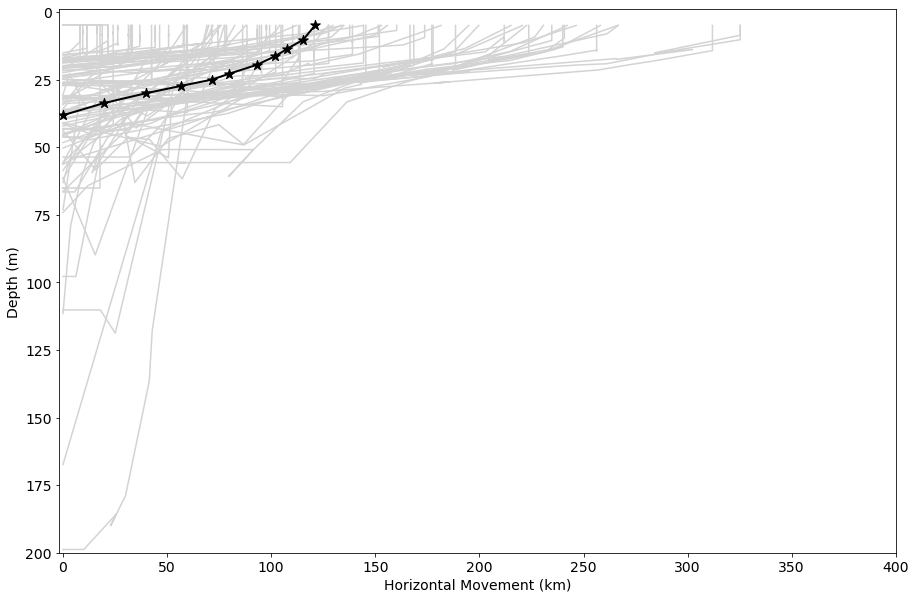

In [297]:
plt.subplots(figsize = [15,10])
for i in range(100):
    plt.plot(total_horiz50neus[i,:],total_depth50neus[i,:],color = 'lightgrey')
#plt.scatter(total_horiz50neus[np.where(exited_h>0)],total_depth50neus[np.where(exited_h>0)], c = 'red', s =25)
#plt.scatter(total_horiz50neus[np.where(exited_d>0)],total_depth50neus[np.where(exited_d>0)], c = 'blue', s =25)

    #plt.scatter(total_horiz50neus[i,:],total_depth50neus[i,:], c = exited_d[i,:], cmap = 'Purples')
x=np.nanmean(total_horiz50neus[:,:],0)
y=np.nanmean(total_depth50neus[:,:],0)
n = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
#for i, txt in enumerate(n):
#    plt.annotate(txt, (x[i]+1, y[i]+1), fontsize = 12)
plt.scatter(np.nanmean(total_horiz50neus[:,:],0),np.nanmean(total_depth50neus[:,:],0), marker = "*", color = 'k', s = 105, zorder = 110)
plt.plot(np.nanmean(total_horiz50neus[:,:],0),np.nanmean(total_depth50neus[:,:],0), linewidth = 2, color = 'k')
plt.xlim(-2,400)
plt.tick_params(labelsize = 14)
plt.ylim(200,-1)
plt.ylabel('Depth (m)', fontsize = 14)
plt.xlabel('Horizontal Movement (km)', fontsize =14)

Text(0.5, 0, 'Horizontal Movement (km)')

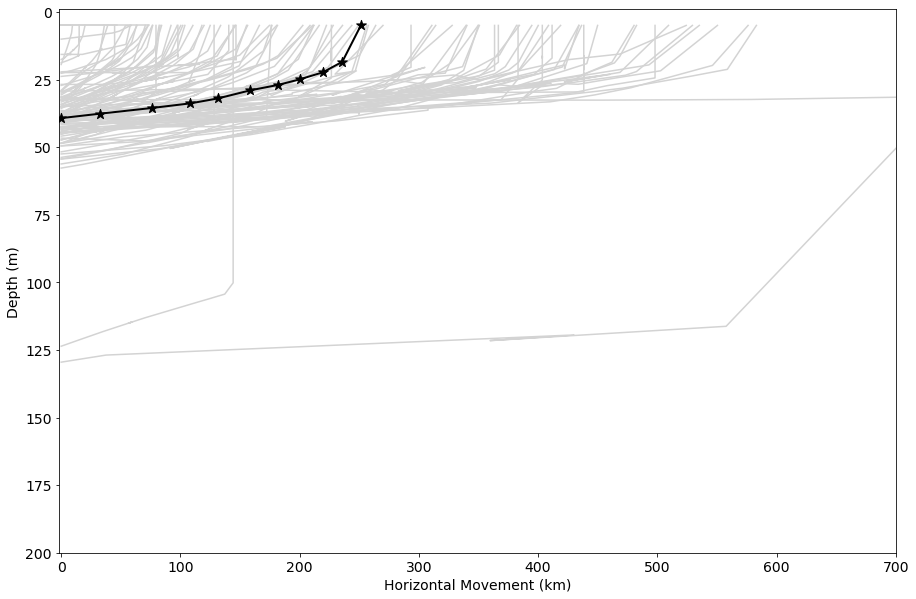

In [349]:
plt.subplots(figsize = [15,10])
for i in range(100):
    plt.plot(total_horiz50gome[i,:],total_depth50gome[i,:],color = 'lightgrey')
#plt.scatter(total_horiz50gome[np.where(exited_h>0)],total_depth50gome[np.where(exited_h>0)], c = 'red', s =25)
#plt.scatter(total_horiz50gome[np.where(exited_d>0)],total_depth50gome[np.where(exited_d>0)], c = 'blue', s =25)

    #plt.scatter(total_horiz50gome[i,:],total_depth50gome[i,:], c = exited_d[i,:], cmap = 'Purples')
x=np.nanmean(total_horiz50gome[:,:],0)
y=np.nanmean(total_depth50gome[:,:],0)
n = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
#for i, txt in enumerate(n):
#    plt.annotate(txt, (x[i]+1, y[i]+1), fontsize = 12)
plt.scatter(np.nanmean(total_horiz50gome[:,:],0),np.nanmean(total_depth50gome[:,:],0), marker = "*", color = 'k', s = 105, zorder = 110)
plt.plot(np.nanmean(total_horiz50gome[:,:],0),np.nanmean(total_depth50gome[:,:],0), linewidth = 2, color = 'k')
plt.xlim(-2,700)
plt.tick_params(labelsize = 14)
plt.ylim(200,-1)
plt.ylabel('Depth (m)', fontsize = 14)
plt.xlabel('Horizontal Movement (km)', fontsize =14)

Text(0.5, 0, 'Horizontal Movement (km)')

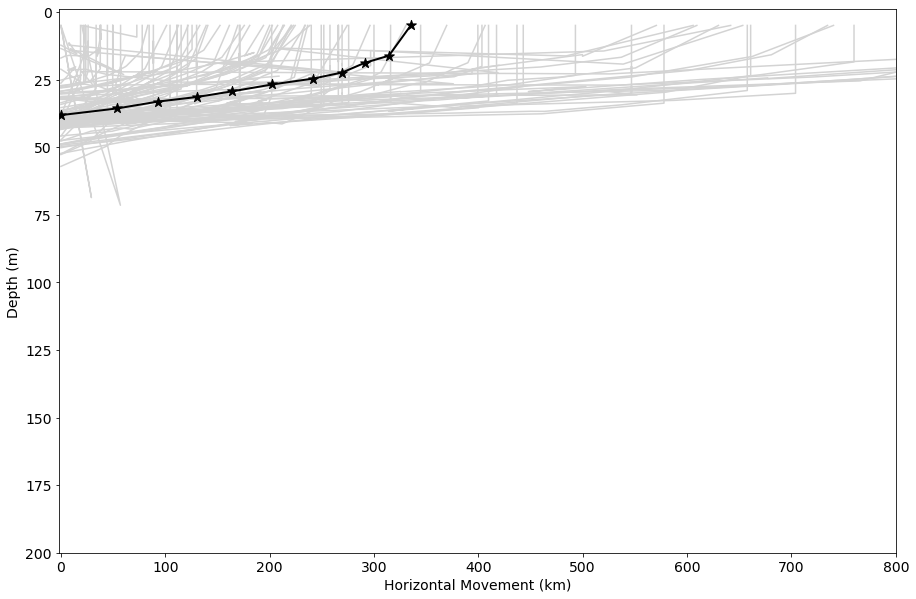

In [351]:
plt.subplots(figsize = [15,10])
for i in range(100):
    plt.plot(total_horiz50ebes[i,:],total_depth50ebes[i,:],color = 'lightgrey')
#plt.scatter(total_horiz50gome[np.where(exited_h>0)],total_depth50gome[np.where(exited_h>0)], c = 'red', s =25)
#plt.scatter(total_horiz50gome[np.where(exited_d>0)],total_depth50gome[np.where(exited_d>0)], c = 'blue', s =25)

    #plt.scatter(total_horiz50gome[i,:],total_depth50gome[i,:], c = exited_d[i,:], cmap = 'Purples')
x=np.nanmean(total_horiz50ebes[:,:],0)
y=np.nanmean(total_depth50ebes[:,:],0)
n = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
#for i, txt in enumerate(n):
#    plt.annotate(txt, (x[i]+1, y[i]+1), fontsize = 12)
plt.scatter(np.nanmean(total_horiz50ebes[:,:],0),np.nanmean(total_depth50ebes[:,:],0), marker = "*", color = 'k', s = 105, zorder = 110)
plt.plot(np.nanmean(total_horiz50ebes[:,:],0),np.nanmean(total_depth50ebes[:,:],0), linewidth = 2, color = 'k')
plt.xlim(-2,800)
plt.tick_params(labelsize = 14)
plt.ylim(200,-1)
plt.ylabel('Depth (m)', fontsize = 14)
plt.xlabel('Horizontal Movement (km)', fontsize =14)

Text(0.5, 0, 'Horizontal Movement (km)')

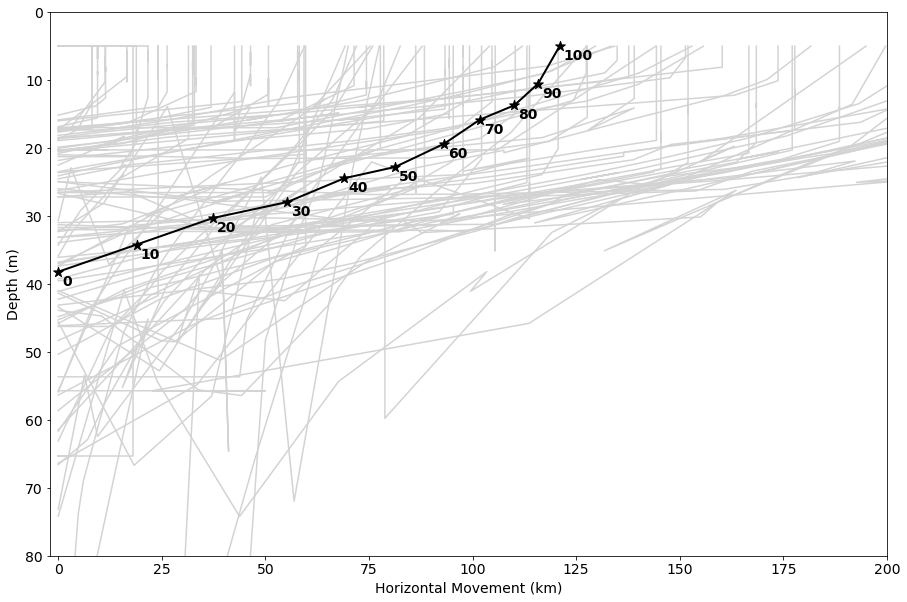

In [348]:
plt.subplots(figsize = [15,10])
for i in range(100):
    plt.plot(total_horiz50neus[i,:],total_depth50neus[i,:],color = 'lightgrey')
#plt.scatter(total_horiz50neus[np.where(exited_h>0)],total_depth50neus[np.where(exited_h>0)], c = 'red', s =25)
#plt.scatter(total_horiz50neus[np.where(exited_d>0)],total_depth50neus[np.where(exited_d>0)], c = 'blue', s =25)

    #plt.scatter(total_horiz50neus[i,:],total_depth50neus[i,:], c = exited_d[i,:], cmap = 'Purples')
x=np.nanmean(total_horiz50neus[:,:],0)
y=np.nanmean(total_depth50neus[:,:],0)
n = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for i, txt in enumerate(n):
    plt.annotate(txt, (x[i]+1, y[i]+2), fontsize = 14,fontweight = 'bold')
plt.plot(np.nanmean(total_horiz50neus[:,:],0),np.nanmean(total_depth50neus[:,:],0), linewidth = 2, color = 'k')
plt.scatter(np.nanmean(total_horiz50neus[:,:],0),np.nanmean(total_depth50neus[:,:],0), marker = "*", color = 'k', s = 105, zorder = 110)
plt.xlim(-2,200)
plt.tick_params(labelsize = 14)
plt.ylim(80,0)
plt.ylabel('Depth (m)', fontsize = 14)
plt.xlabel('Horizontal Movement (km)', fontsize =14)

Text(0.5, 0, 'Horizontal Movement (km)')

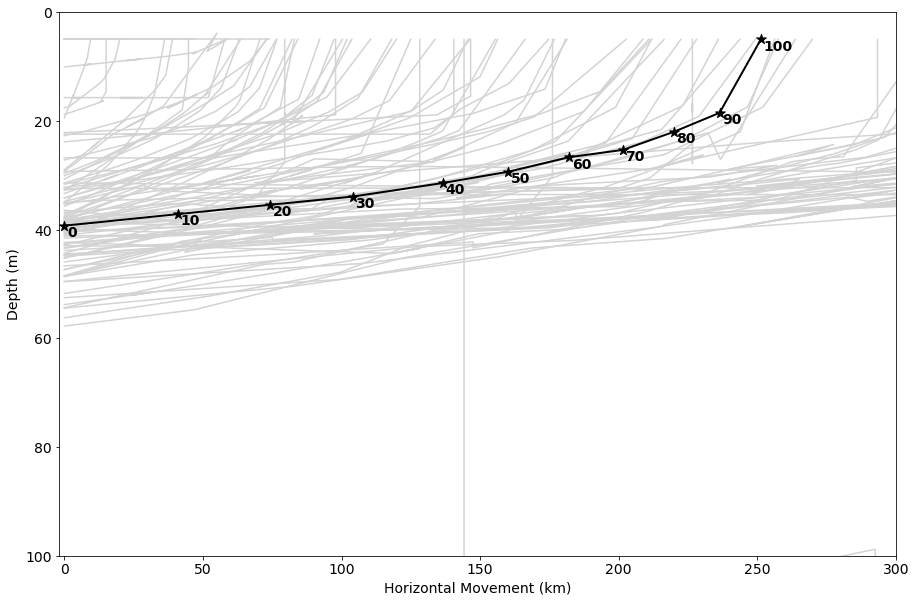

In [310]:
plt.subplots(figsize = [15,10])
for i in range(100):
    plt.plot(total_horiz50gome[i,:],total_depth50gome[i,:],color = 'lightgrey')
#plt.scatter(total_horiz50gome[np.where(exited_h>0)],total_depth50gome[np.where(exited_h>0)], c = 'red', s =25)
#plt.scatter(total_horiz50gome[np.where(exited_d>0)],total_depth50gome[np.where(exited_d>0)], c = 'blue', s =25)

    #plt.scatter(total_horiz50gome[i,:],total_depth50gome[i,:], c = exited_d[i,:], cmap = 'Purples')
x=np.nanmean(total_horiz50gome[:,:],0)
y=np.nanmean(total_depth50gome[:,:],0)
n = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for i, txt in enumerate(n):
    plt.annotate(txt, (x[i]+1, y[i]+2), fontsize = 14,fontweight = 'bold')
plt.plot(np.nanmean(total_horiz50gome[:,:],0),np.nanmean(total_depth50gome[:,:],0), linewidth = 2, color = 'k')
plt.scatter(np.nanmean(total_horiz50gome[:,:],0),np.nanmean(total_depth50gome[:,:],0), marker = "*", color = 'k', s = 105, zorder = 110)
plt.xlim(-2,300)
plt.tick_params(labelsize = 14)
plt.ylim(100,0)
plt.ylabel('Depth (m)', fontsize = 14)
plt.xlabel('Horizontal Movement (km)', fontsize =14)

Text(0.5, 0, 'Horizontal Movement (km)')

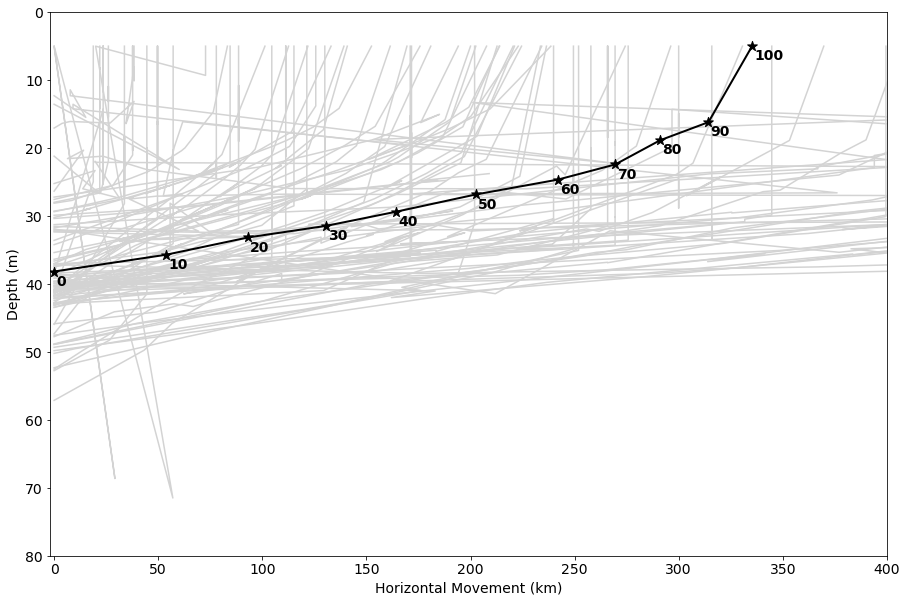

In [353]:
plt.subplots(figsize = [15,10])
for i in range(100):
    plt.plot(total_horiz50ebes[i,:],total_depth50ebes[i,:],color = 'lightgrey')
#plt.scatter(total_horiz50gome[np.where(exited_h>0)],total_depth50gome[np.where(exited_h>0)], c = 'red', s =25)
#plt.scatter(total_horiz50gome[np.where(exited_d>0)],total_depth50gome[np.where(exited_d>0)], c = 'blue', s =25)

    #plt.scatter(total_horiz50gome[i,:],total_depth50gome[i,:], c = exited_d[i,:], cmap = 'Purples')
x=np.nanmean(total_horiz50ebes[:,:],0)
y=np.nanmean(total_depth50ebes[:,:],0)
n = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for i, txt in enumerate(n):
    plt.annotate(txt, (x[i]+1, y[i]+2), fontsize = 14,fontweight = 'bold')
plt.plot(np.nanmean(total_horiz50ebes[:,:],0),np.nanmean(total_depth50ebes[:,:],0), linewidth = 2, color = 'k')
plt.scatter(np.nanmean(total_horiz50ebes[:,:],0),np.nanmean(total_depth50ebes[:,:],0), marker = "*", color = 'k', s = 105, zorder = 110)
plt.xlim(-2,400)
plt.tick_params(labelsize = 14)
plt.ylim(80,0)
plt.ylabel('Depth (m)', fontsize = 14)
plt.xlabel('Horizontal Movement (km)', fontsize =14)

Text(0.5, 0, 'Horizontal Movement (km)')

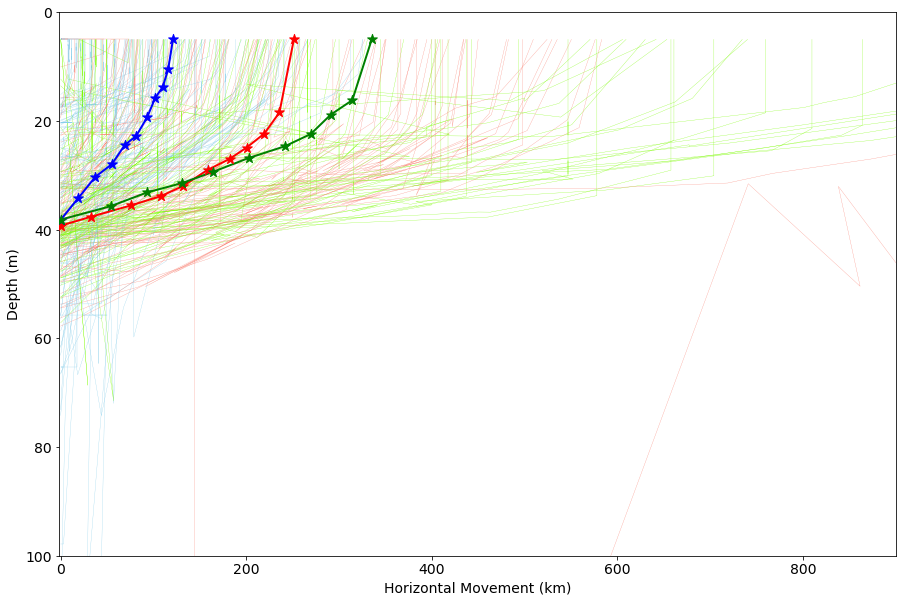

In [354]:
plt.subplots(figsize = [15,10])
for i in range(100):
    plt.plot(total_horiz50gome[i,:],total_depth50gome[i,:],color = 'salmon', linewidth = 0.25)
    plt.plot(total_horiz50neus[i,:],total_depth50neus[i,:],color = 'skyblue', linewidth = 0.25)
    plt.plot(total_horiz50ebes[i,:],total_depth50ebes[i,:],color = 'lawngreen', linewidth = 0.25)
#plt.scatter(total_horiz50gome[np.where(exited_h>0)],total_depth50gome[np.where(exited_h>0)], c = 'red', s =25)
#plt.scatter(total_horiz50gome[np.where(exited_d>0)],total_depth50gome[np.where(exited_d>0)], c = 'blue', s =25)

    #plt.scatter(total_horiz50gome[i,:],total_depth50gome[i,:], c = exited_d[i,:], cmap = 'Purples')
#x=np.nanmean(total_horiz50gome[:,:],0)
#y=np.nanmean(total_depth50gome[:,:],0)
#n = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
#for i, txt in enumerate(n):
#    plt.annotate(txt, (x[i]+1, y[i]+2), fontsize = 14,fontweight = 'bold')
plt.plot(np.nanmean(total_horiz50gome[:,:],0),np.nanmean(total_depth50gome[:,:],0), linewidth = 2, color = 'r')
plt.scatter(np.nanmean(total_horiz50gome[:,:],0),np.nanmean(total_depth50gome[:,:],0), marker = "*", color = 'r', s = 105, zorder = 110)
plt.plot(np.nanmean(total_horiz50neus[:,:],0),np.nanmean(total_depth50neus[:,:],0), linewidth = 2, color = 'b')
plt.scatter(np.nanmean(total_horiz50neus[:,:],0),np.nanmean(total_depth50neus[:,:],0), marker = "*", color = 'b', s = 105, zorder = 110)
plt.plot(np.nanmean(total_horiz50ebes[:,:],0),np.nanmean(total_depth50ebes[:,:],0), linewidth = 2, color = 'g')
plt.scatter(np.nanmean(total_horiz50ebes[:,:],0),np.nanmean(total_depth50ebes[:,:],0), marker = "*", color = 'g', s = 105, zorder = 110)

plt.xlim(-2,900)
plt.tick_params(labelsize = 14)
plt.ylim(100,0)
plt.ylabel('Depth (m)', fontsize = 14)
plt.xlabel('Horizontal Movement (km)', fontsize =14)

In [346]:
exited_horiz_neus = pn.Series(np.sum(exited_h_neus,0))
exited_depth_neus = pn.Series(np.sum(exited_d_neus,0))
exited_depthup_neus = pn.Series(np.sum(exited_dup_neus,0))

exited_horiz_gome = pn.Series(np.sum(exited_h_gome,0))
exited_depth_gome = pn.Series(np.sum(exited_d_gome,0))
exited_depthup_gome = pn.Series(np.sum(exited_dup_gome,0))

exited_horiz_ebes = pn.Series(np.sum(exited_h_ebes,0))
exited_depth_ebes = pn.Series(np.sum(exited_d_ebes,0))
exited_depthup_ebes = pn.Series(np.sum(exited_dup_ebes,0))

exited_table = pn.DataFrame({'Percent Chance Horizontal': np.arange(0,110,10),
                             'Horizontal_neus': exited_horiz_neus,
                             'Bottom_neus': exited_depth_neus,
                             'Surface_neus': exited_depthup_neus,
                             'Horizontal_gome': exited_horiz_gome,
                             'Bottom_gome': exited_depth_gome,
                             'Surface_gome': exited_depthup_gome,
                             'Horizontal_ebes': exited_horiz_ebes,
                             'Bottom_ebes': exited_depth_ebes,
                             'Surface_ebes': exited_depthup_ebes})

In [347]:
exited_table

,Percent Chance Horizontal,Horizontal_neus,Bottom_neus,Surface_neus,Horizontal_gome,Bottom_gome,Surface_gome,Horizontal_ebes,Bottom_ebes,Surface_ebes
0,0,0.0,24.0,3.0,0.0,5.0,2.0,0.0,14.0,0.0
1,10,0.0,24.0,5.0,0.0,4.0,2.0,6.0,13.0,0.0
2,20,13.0,15.0,3.0,0.0,4.0,2.0,15.0,15.0,0.0
3,30,20.0,12.0,3.0,2.0,4.0,2.0,21.0,14.0,0.0
4,40,27.0,8.0,3.0,2.0,4.0,2.0,27.0,11.0,0.0
5,50,34.0,6.0,2.0,8.0,3.0,2.0,38.0,8.0,0.0
6,60,43.0,4.0,2.0,8.0,2.0,2.0,42.0,5.0,0.0
7,70,50.0,3.0,2.0,9.0,2.0,2.0,47.0,4.0,0.0
8,80,58.0,1.0,2.0,13.0,2.0,2.0,50.0,4.0,0.0
9,90,65.0,1.0,2.0,18.0,0.0,2.0,55.0,0.0,0.0


In [ ]:
np.where(total_depth50neus > 200)

In [ ]:
depth50neus[:,40,1]

In [ ]:
lat_index = int(lat_indices_neus[40])

In [ ]:
lon_index = int(lon_indices_neus[40])

In [ ]:
depth_mov = neus.VCV[lat_index,lon_index,17]

In [ ]:
depth_mov

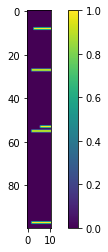

In [123]:
plt.imshow(exited_h)
plt.colorbar()

In [ ]:
plt.scatter(total_horiz50neus[np.where(exited_h>0)],total_depth50neus[np.where(exited_h>0)], c = 'red', s =25)
plt.scatter(total_horiz50neus[np.where(exited_d>0)],total_depth50neus[np.where(exited_d>0)], c = 'blue', s =25)

In [49]:
LME,

NotImplementedError: A polygon does not itself provide the array interface. Its rings do.

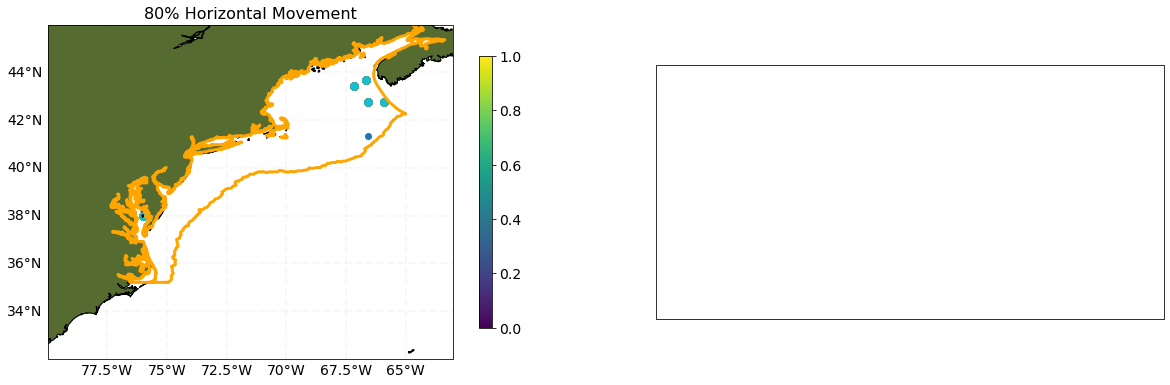

In [154]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [280,297,32,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())
#cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
#cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(LME[LME.LME_NAME == 'Northeast U.S. Continental Shelf'].geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('80% Horizontal Movement', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')
for i in range(50):
    c = ax[0].scatter(new_lon50neus[0,[np.where(exited_h>0)][0][0], [np.where(exited_h>0)][0][1]],new_lat50neus[0,[np.where(exited_h>0)][0][0], [np.where(exited_h>0)][0][1]], s=50)#, c = np.arange(2024,2074), cmap = 'viridis')
ax[0].scatter(new_lon50neus[0,0,10], new_lat50neus[0,0,10])
#ax[0].scatter(new_lon50[:,2,8], new_lat50[:,2,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,3,8], new_lat50[:,3,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,4,8], new_lat50[:,4,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,5,8], new_lat50[:,5,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,6,8], new_lat50[:,6,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,7,8], new_lat50[:,7,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,8,8], new_lat50[:,8,8], c = np.arange(2024,2074), cmap = 'viridis')
cbar = plt.colorbar(c, ax = ax[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=14) 

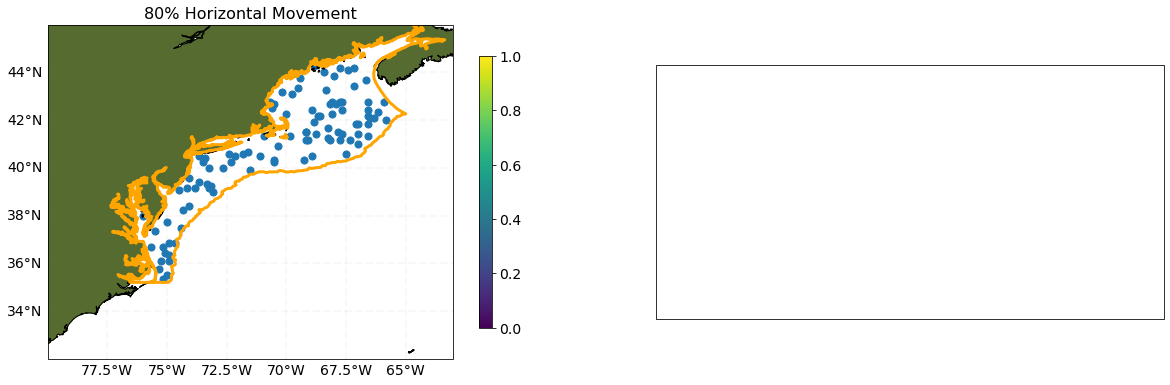

In [125]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
gl = ax[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 14, 'color': 'k'}
gl.xlabel_style = {'size': 14, 'color': 'k'}
extent = [280,297,32,46]
ax[0].set_extent(extent)
ax[0].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())
#cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
#cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0].add_geometries(LME[LME.LME_NAME == 'Northeast U.S. Continental Shelf'].geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
ax[0].set_title('80% Horizontal Movement', fontsize = 16)
ax[0].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')

c = ax[0].scatter(neus_h.lon[(lon_indices_neus.astype(int))],neus_h.lat[(lat_indices_neus.astype(int))], s=50)#, c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,1,8], new_lat50[:,1,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,2,8], new_lat50[:,2,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,3,8], new_lat50[:,3,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,4,8], new_lat50[:,4,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,5,8], new_lat50[:,5,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,6,8], new_lat50[:,6,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,7,8], new_lat50[:,7,8], c = np.arange(2024,2074), cmap = 'viridis')
#ax[0].scatter(new_lon50[:,8,8], new_lat50[:,8,8], c = np.arange(2024,2074), cmap = 'viridis')
cbar = plt.colorbar(c, ax = ax[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=14) 

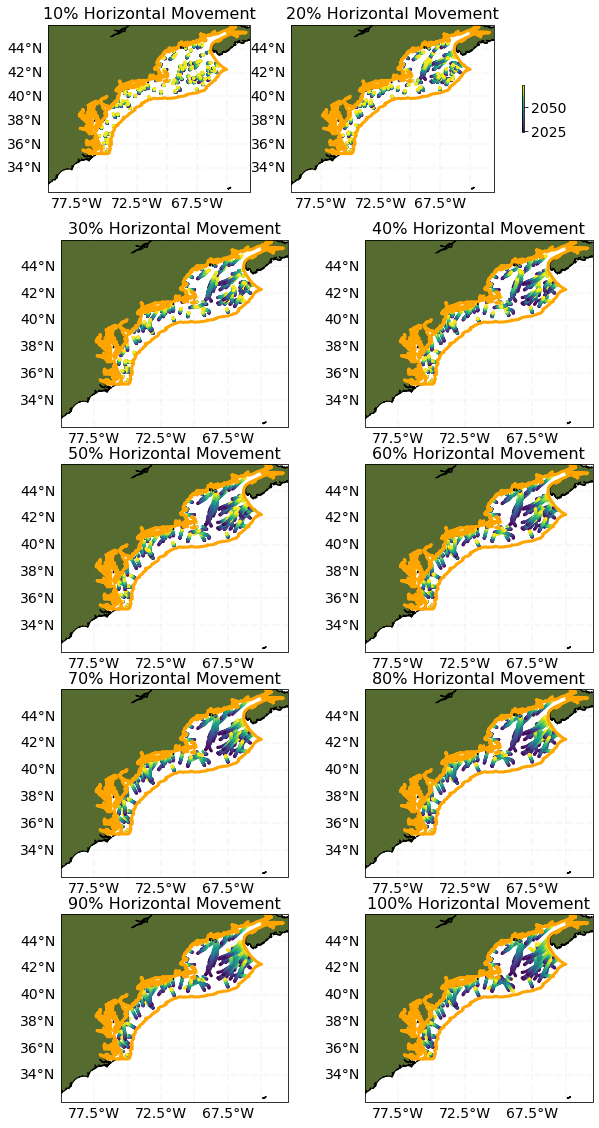

In [295]:
row_index = [0,0,1,1,2,2,3,3,4,4]
col_index = [0,1,0,1,0,1,0,1,0,1]

title_labels = np.arange(10,110,10)

fig,ax = plt.subplots(nrows = 5, ncols = 2, figsize = [10,20],subplot_kw={'projection': ccrs.PlateCarree()})
for i in range(10):
    gl = ax[row_index[i], col_index[i]].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
    gl.xlabels_top = False
    gl.ylabels_right = False
    gl.ylabel_style = {'size': 14, 'color': 'k'}
    gl.xlabel_style = {'size': 14, 'color': 'k'}
    extent = [280,297,32,46]
    ax[row_index[i], col_index[i]].set_extent(extent)
    ax[row_index[i], col_index[i]].coastlines(resolution='10m')
#CS = ax[0].contourf(neus_h.lon,neus_h.lat,neus_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())
#cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
#cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
    ax[row_index[i], col_index[i]].add_geometries(LME[LME.LME_NAME == 'Northeast U.S. Continental Shelf'].geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
    title_string = str(title_labels[i]) + '% Horizontal Movement'
    ax[row_index[i], col_index[i]].set_title(title_string, fontsize = 16)
    ax[row_index[i], col_index[i]].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')
    for j in range(100):
        c = ax[row_index[i], col_index[i]].scatter(new_lon50neus[:,j,i+1], new_lat50neus[:,j,i+1], c = np.arange(2024,2074), cmap = 'viridis', s =5)
cbar = plt.colorbar(c, ax = ax[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=14) 

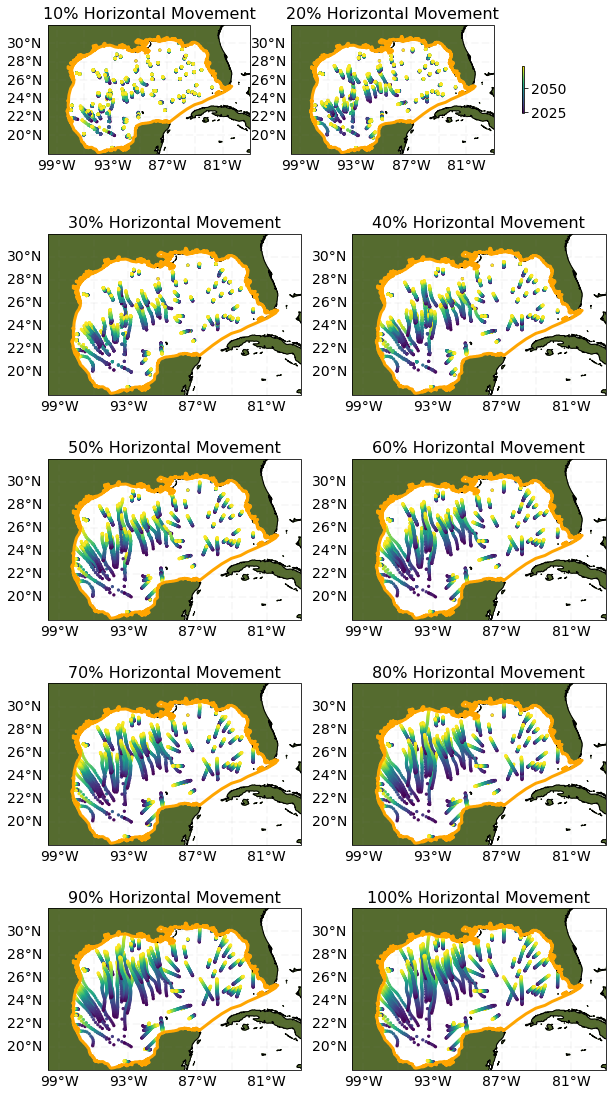

In [320]:
row_index = [0,0,1,1,2,2,3,3,4,4]
col_index = [0,1,0,1,0,1,0,1,0,1]

title_labels = np.arange(10,110,10)

fig,ax = plt.subplots(nrows = 5, ncols = 2, figsize = [10,20],subplot_kw={'projection': ccrs.PlateCarree()})
for i in range(10):
    gl = ax[row_index[i], col_index[i]].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
    gl.xlabels_top = False
    gl.ylabels_right = False
    gl.ylabel_style = {'size': 14, 'color': 'k'}
    gl.xlabel_style = {'size': 14, 'color': 'k'}
    extent = [260,282,18,32]
    ax[row_index[i], col_index[i]].set_extent(extent)
    ax[row_index[i], col_index[i]].coastlines(resolution='10m')
#CS = ax[0].contourf(gome_h.lon,gome_h.lat,gome_h.ew_spatgrad,levels = np.arange(-.010, .010, .0005), extend = 'both',cmap='bwr',linewidths = 2.5,transform=ccrs.PlateCarree())
#cbar = plt.colorbar(CS,shrink=0.25, ax = ax[0])
#cbar.ax.tick_params(labelsize=14) 
#ax[0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0].clabel(CS, fontsize=20, inline=1, fmt=text2)
#ax[0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
    ax[row_index[i], col_index[i]].add_geometries(LME[LME.LME_NAME == 'Gulf of Mexico'].geometry, ccrs.PlateCarree(), facecolor='none', edgecolor = 'orange', linewidth =3)#hatch='xxxx')
    title_string = str(title_labels[i]) + '% Horizontal Movement'
    ax[row_index[i], col_index[i]].set_title(title_string, fontsize = 16)
    ax[row_index[i], col_index[i]].add_feature(cartopy.feature.LAND, color = 'darkolivegreen')

#ax[0].scatter(new_lon[:,0], new_lat, color = 'yellow')
    for j in range(100):
        c = ax[row_index[i], col_index[i]].scatter(new_lon50gome[:,j,i+1], new_lat50gome[:,j,i+1], c = np.arange(2024,2074), cmap = 'viridis', s =5)
cbar = plt.colorbar(c, ax = ax[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=14) 

In [292]:
np.shape(new_lon50neus)

(50, 100, 11)

In [89]:
np.shape(new_lat50neus[:,[np.where(exited_h>0)][0][0], [np.where(exited_h>0)][0][1]])

(41,)

In [98]:
np.shape(new_lon50neus)

(50, 100, 11)

In [99]:
np.where(exited_h>0)

(array([ 8,  8,  8,  8,  8,  8,  8,  8, 27, 27, 27, 27, 27, 27, 27, 27, 27,
        27, 53, 53, 53, 53, 53, 55, 55, 55, 55, 55, 55, 55, 55, 55, 97, 97,
        97, 97, 97, 97, 97, 97, 97]),
 array([ 3,  4,  5,  6,  7,  8,  9, 10,  1,  2,  3,  4,  5,  6,  7,  8,  9,
        10,  3,  4,  7,  9, 10,  2,  3,  4,  5,  6,  7,  8,  9, 10,  2,  3,
         4,  5,  6,  7,  8,  9, 10]))